In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# =========================
# 1. Import thư viện
# =========================
import pandas as pd
from urllib.parse import urlparse, parse_qs

# =========================
# 2. Load dữ liệu
# =========================
# Upload file lên Colab rồi sửa path
df = pd.read_csv('/content/drive/MyDrive/ATPM/Payloads.csv', encoding="latin1")

# =========================
# 3. Kiểm tra URL
# =========================
def is_full_url(payload):
    try:
        if not isinstance(payload, str):
            return False

        payload = payload.strip()

        parsed = urlparse(payload)
        return bool(parsed.netloc)
    except:
        return False

# =========================
# 4. Kiểm tra có parameter
# =========================
def has_query_param(payload):
    try:
        if not isinstance(payload, str):
            return False

        payload = payload.strip()

        parsed = urlparse(payload)
        return len(parse_qs(parsed.query)) > 0
    except:
        return False

# =========================
# 5. Apply vào dataset
# =========================
df['is_url'] = df['Payloads'].apply(is_full_url)
df['has_param'] = df['Payloads'].apply(has_query_param)
empty_mask = (
    df['Payloads'].isna() |                 # NaN
    (df['Payloads'].astype(str).str.strip() == '')  # chuỗi rỗng hoặc toàn khoảng trắng
)
num_empty = empty_mask.sum()
total = len(df)


# =========================
# 6. Thống kê
# =========================
total = len(df)

num_url = df['is_url'].sum()
num_not_url = total - num_url

# URL có param
num_url_with_param = df[(df['is_url']) & (df['has_param'])].shape[0]

# URL không param
num_url_no_param = df[(df['is_url']) & (~df['has_param'])].shape[0]

# =========================
# 7. In kết quả
# =========================
print("\n===== THỐNG KÊ =====")
print(f"Tổng số payload                 : {total}")
print(f"Số payload là URL               : {num_url}")
print(f"Số payload KHÔNG phải URL       : {num_not_url}")

print("\n--- URL ---")
print(f"URL có parameter                : {num_url_with_param}")
print(f"URL KHÔNG có parameter          : {num_url_no_param}")

print(f"Số payload rỗng: {num_empty}")
print(f"Tỷ lệ: {num_empty / total:.4f}")

# # =========================
# # 8. (Optional) Xem ví dụ từng loại
# # =========================
# print("\nVí dụ URL có param:")
# print(df[(df['is_url']) & (df['has_param'])]['Payloads'].head())

# print("\nVí dụ URL không param:")
# print(df[(df['is_url']) & (~df['has_param'])]['Payloads'].head())

# print("\nVí dụ không phải URL:")
# print(df[~df['is_url']]['Payloads'].head())


===== THỐNG KÊ =====
Tổng số payload                 : 43217
Số payload là URL               : 27719
Số payload KHÔNG phải URL       : 15498

--- URL ---
URL có parameter                : 14974
URL KHÔNG có parameter          : 12745
Số payload rỗng: 1
Tỷ lệ: 0.0000


In [ ]:
import pandas as pd
import re, string, base64, binascii
import unicodedata
import html
from urllib.parse import unquote_plus, urlsplit, parse_qsl
from typing import List, Dict, Tuple


df = pd.read_csv("/content/drive/MyDrive/ATPM/Payloads.csv", encoding="latin1")
# pd.set_option('display.max_colwidth', None)
invalid_rows = []

# =======================
# Decoding / normalization pipeline

JS_UHEX_RE = re.compile(r"\\u([0-9a-fA-F]{4})")
JS_XHEX_RE = re.compile(r"\\x([0-9a-fA-F]{2})")

# Bắt cả decimal và 0x.. (String.fromCharCode / fromCharCode)
FROMCHARCODE_RE = re.compile(
    r"(?:string\.)?fromcharcode\s*\(\s*([0-9xXa-fA-F,\s]+)\s*\)",
    re.IGNORECASE
)

# Base64 token-level (giữ như cũ)
B64_RE = re.compile(
    r"(?<![A-Za-z0-9+/=_-])"
    r"(?=[A-Za-z0-9+/=_-]{16,}(?![A-Za-z0-9+/=_-]))"  # >=16 chars
    r"(?=.*[+/=_-])"                                   # có ít nhất 1 ký tự đặc trưng
    r"(?:[A-Za-z0-9+/_-]{4}){4,}"                       # >=16 chars, bội số 4
    r"(?:[A-Za-z0-9+/_-]{2}==|[A-Za-z0-9+/_-]{3}=)?"
    r"(?![A-Za-z0-9+/=_-])"
)

# HEX token-level: yêu cầu byte-pairs đủ dài + PHẢI có ít nhất 1 chữ a-f
# để tránh match chuỗi chỉ toàn số như 1974630082144363
HEX_RE = re.compile(
    r"(?<![0-9A-Fa-f])"
    r"(?=[0-9A-Fa-f]{16,}(?![0-9A-Fa-f]))"   # tối thiểu 16 hex chars
    r"(?=.*[A-Fa-f])"                        # bắt buộc có chữ a-f
    r"(?:[0-9A-Fa-f]{2}){8,}"
    r"(?![0-9A-Fa-f])"
)

PCT_RE = re.compile(r"%([0-9A-Fa-f]{2})")

def unquote_plus_ascii_only(s: str) -> str:

    def repl(m):
        b = int(m.group(1), 16)
        # chỉ decode các byte ASCII an toàn
        if b < 0x80:
            return chr(b)
        # giữ nguyên percent-encoding cho byte cao
        return m.group(0)

    return PCT_RE.sub(repl, s)

def _has_key_only_params(q):
    # q là list (k, v). key-only thường có v == "" và key không rỗng
    # nhưng keep_blank_values=True nên param dạng a= cũng có v==""
    # ta phân biệt bằng: token key-only thường chứa ';' hoặc 'lt' 'gt' 'quot'... hoặc không giống key bình thường
    for k, v in q:
        if v == "" and k and (";" in k or k.lower().startswith(("quot", "lt", "gt", "#"))):
            return True
    return False

def _parse_query_normal(query: str):
    return parse_qsl(query, keep_blank_values=True)

def _mostly_printable(s: str, min_ratio: float = 0.9) -> bool:
    """Trả True nếu phần lớn ký tự là printable (tránh control chars)."""
    if not s:
        return False
    printable = set(string.printable)
    good = sum(ch in printable for ch in s)
    return (good / len(s)) >= min_ratio

def _js_unicode_unescape(s: str) -> str:
    s = JS_UHEX_RE.sub(lambda m: chr(int(m.group(1), 16)), s)
    return JS_XHEX_RE.sub(lambda m: chr(int(m.group(1), 16)), s)

def _from_charcode_replace(m: re.Match) -> str:
    raw = m.group(1)
    parts = [p.strip() for p in raw.split(",") if p.strip()]

    out = []
    for p in parts:
        try:
            n = int(p, 0)  # hỗ trợ 0x.. và decimal
            if 0 <= n <= 0x10FFFF:
                out.append(chr(n))
        except ValueError:
            return m.group(0)
    decoded = "".join(out)
    return f"string.fromcharcode({decoded})"

def _b64_decode_token(token: str) -> str:
    padded = token + "=" * ((4 - (len(token) & 3)) & 3)
    try:
        decoded = base64.b64decode(padded, validate=False)
        out = decoded.decode("utf-8", errors="ignore")
    except (binascii.Error, ValueError):
        return token

    # Chỉ chấp nhận nếu decode ra chuỗi “nhìn được”
    return out if _mostly_printable(out, 0.9) else token

def _hex_decode_token(token: str) -> str:
    # Chặn số thuần (extra safety)
    if token.isdigit():
        return token

    try:
        decoded = binascii.unhexlify(token)
        out = decoded.decode("utf-8", errors="ignore")
    except (binascii.Error, ValueError):
        return token

    # Chỉ chấp nhận nếu decode ra chuỗi “nhìn được”
    return out if _mostly_printable(out, 0.9) else token

def decode_layers(s: str, rounds: int = 3) -> str:
    if s is None:
        return ""

    s = str(s)
    prev = None

    for _ in range(rounds):
        if s == prev:
            break
        prev = s

        # URL decode + HTML decode
        s = unquote_plus_ascii_only(s)
        s = html.unescape(s)

        # JS escape decode
        s = _js_unicode_unescape(s)
        s = FROMCHARCODE_RE.sub(_from_charcode_replace, s)

        # token-level decode base64/hex (đã có gating)
        s = B64_RE.sub(lambda m: _b64_decode_token(m.group(0)), s)
        s = HEX_RE.sub(lambda m: _hex_decode_token(m.group(0)), s)

        # normalize
        try:
          s = unicodedata.normalize("NFKC", s)
        except:
          pass

    return s

def url_to_payload_core(full_url: str) -> str:
    """
    - Nếu input là querystring thuần (a=b&c=d...), parse_qsl và chỉ decode trên VALUE
      → tránh phá cấu trúc và tránh decode nhầm số/field.
    - Nếu input là URL đầy đủ: lấy query values.
    - Nếu không parse được: decode toàn chuỗi như fallback.
    """
    if full_url is None:
        return ""

    full_url = str(full_url)

    # URL đầy đủ
    try:
        u = urlsplit(full_url)
    except ValueError:
        return decode_layers(full_url, rounds=3)

    if not (u.scheme and u.netloc):
        return decode_layers(full_url, rounds=3)

    # q1 = _parse_query_normal(u.query)
    q1 = parse_qsl(u.query, keep_blank_values=True)

    # Nếu parse bình thường có dấu hiệu bị "cắt vụn" do &quot;... => thử HTML-DECODE query rồi parse lại
    if _has_key_only_params(q1):
        q2 = _parse_query_normal(html.unescape(u.query))
        # Nếu q2 “đẹp hơn” (ít key-only hơn / nhiều value hơn) thì dùng q2
        if not _has_key_only_params(q2):
            q = q2
        else:
            q = q1
    else:
        q = q1

    values = [decode_layers(v if v else k, rounds=3) for k, v in q]
    core = "\x1f".join(v for v in values if v).strip()
    if len(core) <= 0:
        # payload in last url path
        core = decode_layers(u.path, rounds=6).strip()

    if u.fragment:
        core = (core + " " + decode_layers(u.fragment, rounds=6)).strip()

    return core if core else decode_layers(full_url, rounds=3)

def preprocess(full_url: str) -> str:
    s = url_to_payload_core(full_url)
    s = s.lower()
    s = s.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s



# Create New Data Frame
new_df = pd.DataFrame({
    "Class": df["Class"],
    "Payloads": df["Payloads"].apply(preprocess)
})


In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Validate columns
assert "Payloads" in new_df.columns, f"Missing column: Payloads. Found: {list(df.columns)}"
assert "Class" in new_df.columns, f"Missing column: Class. Found: {list(df.columns)}"

# Warn on unknown classes
unknown = new_df["Payloads"].isna()
if unknown.any():
    print("⚠️ Warning: Unknown Payloads values detected. Unique values:")
    print(df.loc[unknown, "Payloads"].astype(str).str.strip().unique()[:20])

def check_duplicates(df):
    print("\n[+] Checking duplicates...")

    # Tổng số duplicate theo Payloads
    dup_mask = df.duplicated(subset=["Payloads"], keep=False)
    dup_count = dup_mask.sum()
    dup_rows = df.loc[dup_mask]

    print(f"Total duplicate rows (based on Payloads): {dup_count}")

    if dup_count > 0:
        # Số Payloads bị trùng (unique)
        dup_unique = df.loc[dup_mask, "Payloads"].nunique()
        print(f"Unique duplicated Payloads: {dup_unique}")

        # Đếm số lượng label trong các row duplicate
        label_counts_in_duplicates = dup_rows["Class"].value_counts()
        print("\n[+] Duplicate label counts:")
        print(label_counts_in_duplicates)

        # Nếu muốn xem số lượng label unique trong duplicate
        print(f"\nTotal unique labels in duplicates: {dup_rows['Class'].nunique()}")

        conflict = (
            df.loc[dup_mask]
            .groupby("Payloads")["Class"]
            .nunique()
        )

        conflict_cases = conflict[conflict > 1]
        if len(conflict_cases) > 0:
            print("\n⚠️ Found label conflicts in duplicated Payloads!")
            print(f"\nConflict Payloads: {len(conflict_cases)}")

            # print("\n===== Conflict Details =====")

            # for payload in conflict_cases.index:
            #     rows = df[df["Payloads"] == payload]
            #     print(f"\nPayload: {payload}")
            #     print(f"Indexes: {rows.index.tolist()}")
            #     print(f"Classes: {rows['Class'].tolist()}")

        else:
            print("No label conflicts in duplicates.")

    else:
        print("No duplicate Payloads found.")
check_duplicates(new_df)

# tìm payload conflict trên dữ liệu gốc
dup_mask = new_df.duplicated(subset=["Payloads"], keep=False)
conflict_payloads = (
    new_df.loc[dup_mask]
    .groupby("Payloads")["Class"]
    .nunique()
)
conflict_payloads = conflict_payloads[conflict_payloads > 1].index

# loại bỏ toàn bộ payload conflict
df_no_conflict = new_df[~new_df["Payloads"].isin(conflict_payloads)].copy()

# sau đó mới drop duplicate bình thường
df_clean = df_no_conflict.drop_duplicates(subset=["Payloads"]).dropna(subset=["Payloads"])

print(f"\nTotal original rows: {len(new_df)}")
print(f"Total clean rows: {len(df_clean)}")

check_duplicates(df_clean)


# Đếm số lượng từng class
counts = df_clean["Class"].value_counts()

print("\n[+] Class counts:")
print(counts)

# Tính tỷ lệ %
ratios = df_clean["Class"].value_counts(normalize=True) * 100

print("\n[+] Class ratios (%):")
print(ratios)



[+] Checking duplicates...
Total duplicate rows (based on Payloads): 6601
Unique duplicated Payloads: 1195

[+] Duplicate label counts:
Class
Malicious    6597
Benign          4
Name: count, dtype: int64

Total unique labels in duplicates: 2

⚠️ Found label conflicts in duplicated Payloads!

Conflict Payloads: 1

Total original rows: 43217
Total clean rows: 37810

[+] Checking duplicates...
Total duplicate rows (based on Payloads): 0
No duplicate Payloads found.

[+] Class counts:
Class
Benign       28065
Malicious     9745
Name: count, dtype: int64

[+] Class ratios (%):
Class
Benign       74.226395
Malicious    25.773605
Name: proportion, dtype: float64


In [ ]:
import re, string, base64, binascii
import unicodedata
import html
from urllib.parse import unquote_plus, urlsplit, parse_qsl
from typing import List, Dict, Tuple

import pandas as pd

# ---------------- Config ----------------
OUTPUT_CSV = "/content/drive/MyDrive/ATPM/features.csv"
TEXT_COL = "Payloads"
CLASS_COL = "Class"
KEEP_ORIGINAL = True
# ----------------------------------------

# =======================
# Table 1: Structural features
# =======================
PUNCTUATION_CHARS: List[str] = [
    "&", "%", "/", "\\", "+", "'", "?", "!", ";", "#", "=", "[", "]", "$",
    "(", ")", "^", "*", ",", "-", "<", ">", "@", "_", ":", "{", "}", "~", ".",
    " ", "|", "¦", '"',
]

PUNCTUATION_COMBOS: List[str] = ["><", "'\"><", "[]", "==", "&#"]


def safe_feature_name(token: str, prefix: str) -> str:
    mapping = {
        "&": "amp",
        "%": "pct",
        "/": "slash",
        "\\": "bslash",
        "+": "plus",
        "'": "squote",
        '"': "dquote",
        "?": "qmark",
        "!": "emark",
        ";": "semi",
        "#": "hash",
        "=": "eq",
        "[": "lbrack",
        "]": "rbrack",
        "$": "dollar",
        "(": "lparen",
        ")": "rparen",
        "^": "caret",
        "*": "star",
        ",": "comma",
        "-": "dash",
        "<": "lt",
        ">": "gt",
        "@": "at",
        "_": "underscore",
        ":": "colon",
        "{": "lbrace",
        "}": "rbrace",
        "~": "tilde",
        ".": "dot",
        " ": "space",
        "|": "pipe",
        "¦": "brokenbar",
    }
    return f"{prefix}_" + "_".join(mapping.get(ch, f"u{ord(ch)}") for ch in token)


# =======================
# Table 2: Keyword features (word-boundary safe where appropriate)
# =======================

WORD_PATTERNS: List[Tuple[str, re.Pattern]] = [
    # Objects
    ("obj_document", re.compile(r"\bdocument\b")),
    ("obj_window", re.compile(r"\bwindow\b")),
    ("obj_iframe", re.compile(r"\biframe\b")),
    ("obj_location", re.compile(r"\blocation\b")),
    ("obj_this", re.compile(r"\bthis\b")),

    # Events
    ("evt_onload", re.compile(r"\bonload\b")),
    ("evt_onerror", re.compile(r"\bonerror\b")),

    # Methods
    ("mth_createelement", re.compile(r"\bcreateelement\b")),
    ("mth_fromcharcode", re.compile(r"\bstring\.fromcharcode\b")),
    ("mth_search", re.compile(r"\bsearch\b")),

    # Attributes (word boundary helps avoid matching "srcset", etc.)
    ("attr_src", re.compile(r"\bsrc\b")),
    ("attr_href", re.compile(r"\bhref\b")),
    ("attr_cookie", re.compile(r"\bcookie\b")),

    # Reserved
    ("kw_var", re.compile(r"\bvar\b")),

    # Protocol
    ("proto_http", re.compile(r"\bhttp\b")),
]

LITERAL_PATTERNS: List[Tuple[str, str]] = [
    # Tags
    ("tag_div", "div"),
    ("tag_img", "img"),
    ("tag_script", "<script"),

    # Functions
    ("fn_eval", "eval("),

    # External file
    ("ext_js", ".js"),
]




# =======================
# Feature extraction (binary presence)
# =======================

def char_type_ratios_ascii(s: str):
    if s is None:
        return 0.0, 0.0, 0.0

    s = str(s)

    # bỏ separator nếu bạn dùng \x1f để join query values
    s = s.replace("\x1f", "")

    n = len(s)
    if n == 0:
        return 0.0, 0.0, 0.0

    letters = 0
    numbers = 0
    symbols = 0

    for ch in s:
        if ('A' <= ch <= 'Z') or ('a' <= ch <= 'z'):
            letters += 1
        elif '0' <= ch <= '9':
            numbers += 1
        else:
            symbols += 1

    return letters / n, numbers / n, symbols / n

def extract_features(s: str) -> Dict[str, int | float]:
    feats: Dict[str, int | float] = {}

    # ======================
    # ASCII Ratio Features
    # ======================
    lr, nr, sr = char_type_ratios_ascii(s)

    feats["letters_ratio"] = lr
    feats["numbers_ratio"] = nr
    feats["symbols_ratio"] = sr

    # ======================
    # Table 1: Structural
    # ======================
    for ch in PUNCTUATION_CHARS:
        feats[safe_feature_name(ch, "punc")] = 1 if ch in s else 0

    for combo in PUNCTUATION_COMBOS:
        feats[safe_feature_name(combo, "combo")] = 1 if combo in s else 0

    # ======================
    # Table 2: Keyword
    # ======================
    for name, pat in WORD_PATTERNS:
        feats[name] = 1 if pat.search(s) else 0

    for name, lit in LITERAL_PATTERNS:
        feats[name] = 1 if lit in s else 0

    return feats

# =======================
# Calculate Readability Feature
# =======================


# ---------- Readability heuristic ----------
VOWELS = set("aeiouAEIOU")
TOKEN_SPLIT_RE = re.compile(r"[^A-Za-z0-9]+")

def tokenize_payload_readability(payload: str):
    return [t for t in TOKEN_SPLIT_RE.split(payload) if t]

def payload_human_readable_by_percentage(payload: str) -> int:
    """
    Trả về 1 nếu payload 'giống văn bản người đọc' theo các ngưỡng heuristic,
    ngược lại trả 0. (dạng int để làm feature)
    """
    words = tokenize_payload_readability(payload)
    total = len(words)
    if total == 0:
        return 0

    alpha_ok = vowel_ok = length_ok = repetition_ok = 0

    # ceil thresholds
    need_alpha  = int(0.45 * total + 0.999999)
    need_vowel  = int(0.40 * total + 0.999999)
    need_length = int(0.70 * total + 0.999999)
    need_rep    = int(0.80 * total + 0.999999)

    for i, w in enumerate(words, start=1):
        n_total = len(w)

        if n_total < 15:
            length_ok += 1

        # 1-pass scan: count alpha + vowels + detect >=3 consecutive
        n_alpha = 0
        n_vowel = 0
        rep_bad = False

        prev = None
        run = 0

        for ch in w:
            # consecutive repetition
            if ch == prev:
                run += 1
                if run >= 3:
                    rep_bad = True
            else:
                prev = ch
                run = 1

            # ASCII alpha (consistent with your tokenization A-Za-z0-9)
            if ('A' <= ch <= 'Z') or ('a' <= ch <= 'z'):
                n_alpha += 1
                if ch in VOWELS:
                    n_vowel += 1

        if not rep_bad:
            repetition_ok += 1

        if n_total > 0 and (n_alpha / n_total) > 0.70:
            alpha_ok += 1

        if n_alpha > 0:
            vr = n_vowel / n_alpha
            if 0.20 < vr < 0.60:
                vowel_ok += 1

        # early exit
        remaining = total - i
        if alpha_ok + remaining < need_alpha:
            return 0
        if vowel_ok + remaining < need_vowel:
            return 0
        if length_ok + remaining < need_length:
            return 0
        if repetition_ok + remaining < need_rep:
            return 0

    return int(
        alpha_ok >= need_alpha and
        vowel_ok >= need_vowel and
        length_ok >= need_length and
        repetition_ok >= need_rep
    )


# =======================
# Main run (Colab cell)
# =======================
# df = read_csv_robust(INPUT_CSV)
df = df_clean.copy().reset_index(drop=True)
# Map Class -> label (0/1)
df["label"] = df[CLASS_COL].astype(str).str.strip().str.lower().map({
    "malicious": 1,
    "benign": 0,
})

# Preprocess URLs into payload core
text_series = df[TEXT_COL].map(preprocess)
feat_df = pd.DataFrame(list(text_series.map(extract_features)))

# Readability feature (0/1)
readability = text_series.map(payload_human_readable_by_percentage)

# Merge + Save
out = pd.concat([feat_df, readability.rename("readability"), df["label"]], axis=1)
out.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Rows:", out.shape[0], "| Added feature cols:", feat_df.shape[1])
out.head()


Saved: /content/drive/MyDrive/ATPM/features.csv
Rows: 37810 | Added feature cols: 61


,letters_ratio,numbers_ratio,symbols_ratio,punc_amp,punc_pct,punc_slash,punc_bslash,punc_plus,punc_squote,punc_qmark,...,attr_cookie,kw_var,proto_http,tag_div,tag_img,tag_script,fn_eval,ext_js,readability,label
0,0.717391,0.000000,0.282609,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
1,0.725000,0.012500,0.262500,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
2,0.785714,0.047619,0.166667,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0.807882,0.004926,0.187192,0,0,1,1,0,0,0,...,1,0,0,0,0,1,0,0,1,1
4,0.687500,0.000000,0.312500,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Đọc dữ liệu
df = pd.read_csv("/content/drive/MyDrive/ATPM/features.csv")  # đổi thành file của bạn

# 2. Kiểm tra nhanh phân bố label (optional)
print(df["label"].value_counts(normalize=True))

# 3. Chia train/test với stratify
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]   # QUAN TRỌNG
)

# 4. Kiểm tra lại phân bố
print("\nTrain distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=True))

# 5. Lưu file
train_df.to_csv("/content/drive/MyDrive/ATPM/train.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/ATPM/test.csv", index=False)

print("\nDone! Saved train.csv and test.csv")

label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

Train distribution:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

Test distribution:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

Done! Saved train.csv and test.csv


In [ ]:
# ======================================
# CONFIG + DATA LOADING
# ======================================

import os
import time
import threading
import numpy as np
import pandas as pd
import psutil

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/train.csv"

TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

ENCODING = "latin1"

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 5
RANDOM_STATE = 42
SCORING = "f1"

# ------------------------
# LOAD DATA
# ------------------------
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, encoding=ENCODING)
assert TARGET_COLUMN in df.columns, f"Missing target column: {TARGET_COLUMN}"

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print("Shape:", X.shape)
print("Class distribution:")
print(y.value_counts(normalize=False))
print("\nClass ratio:")
print(y.value_counts(normalize=True))


# ======================================
# HELPERS
# ======================================

class ResourceMonitor:
    """
    Theo dõi peak RAM và peak CPU của process hiện tại
    trong lúc chạy GridSearchCV.fit(...)
    """
    def __init__(self, sample_interval=0.05):
        self.sample_interval = sample_interval
        self.process = psutil.Process(os.getpid())
        self.stop_event = threading.Event()
        self.thread = None
        self.peak_ram_mb = 0.0
        self.peak_cpu_pct = 0.0

    def _run(self):
        self.process.cpu_percent(interval=None)

        while not self.stop_event.is_set():
            try:
                ram_mb = self.process.memory_info().rss / (1024 ** 2)
                cpu_pct = self.process.cpu_percent(interval=None)

                self.peak_ram_mb = max(self.peak_ram_mb, ram_mb)
                self.peak_cpu_pct = max(self.peak_cpu_pct, cpu_pct)
            except Exception:
                pass

            time.sleep(self.sample_interval)

    def start(self):
        self.thread = threading.Thread(target=self._run, daemon=True)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        if self.thread is not None:
            self.thread.join()


def fit_grid_with_resource_monitor(grid, X_fit, y_fit):
    """
    Chạy grid.fit(X, y) và đo:
    - thời gian
    - peak RAM
    - peak CPU
    """
    monitor = ResourceMonitor(sample_interval=0.05)

    t0 = time.perf_counter()
    monitor.start()
    grid.fit(X_fit, y_fit)
    monitor.stop()
    t1 = time.perf_counter()

    return {
        "grid": grid,
        "fit_time_sec": t1 - t0,
        "peak_ram_mb": monitor.peak_ram_mb,
        "peak_cpu_pct": monitor.peak_cpu_pct
    }


def compute_binary_metrics(y_true, y_pred):
    """
    Tính metrics nhị phân với labels = [0, 1]
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ConfusionMatrix": cm
    }


def make_confusion_matrix_table(cm):
    """
    Format confusion matrix dạng bảng đẹp như hình:
                        Predicted Negative (0)   Predicted Positive (1)
    Actual Negative (0)           TN                       FP
    Actual Positive (1)           FN                       TP
    """
    tn, fp, fn, tp = cm.ravel()

    cm_table = pd.DataFrame(
        {
            "Predicted Negative (0)": [tn, fn],
            "Predicted Positive (1)": [fp, tp]
        },
        index=["Actual Negative (0)", "Actual Positive (1)"]
    )

    return cm_table


# ================================
# GRID SEARCH FOR HYPERPARAMETERS
# ================================

print("\n" + "=" * 80)
print("RUNNING GRID SEARCH")
print("=" * 80)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "SVM Linear": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },

    "SVM Poly": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="poly",
                class_weight="balanced"
            ))
        ]),
        "params": {
            "clf__C": [0.01, 1, 10, 100],
            "clf__degree": [2, 3],
            "clf__gamma": ["scale", "auto"]
        }
    },

    "KNN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [60, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 3, 5]
        }
    }
}

best_models = {}
summary_rows = []
confusion_tables = {}

for name, cfg in param_grids.items():

    print("\n" + "-" * 60)
    print(f"Grid Search: {name}")
    print("-" * 60)

    grid = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        verbose=1,
        refit=True
    )

    # =========================
    # 1) Grid Search + peak RAM/CPU
    # =========================
    gs_result = fit_grid_with_resource_monitor(grid, X, y)
    fitted_grid = gs_result["grid"]

    print(f"\nBest F1: {fitted_grid.best_score_:.4f}")
    print("Best Params:", fitted_grid.best_params_)
    print(f"Grid Search Time     : {gs_result['fit_time_sec']:.4f} s")
    print(f"Grid Search Peak RAM : {gs_result['peak_ram_mb']:.2f} MB")
    print(f"Grid Search Peak CPU : {gs_result['peak_cpu_pct']:.2f}%")

    best_model = fitted_grid.best_estimator_
    best_models[name] = best_model

    # =========================
    # 2) Out-of-Fold prediction cho best model
    # =========================
    y_pred_oof = cross_val_predict(
        estimator=clone(best_model),
        X=X,
        y=y,
        cv=cv,
        method="predict",
        n_jobs=1
    )

    # =========================
    # 3) Metrics từ OOF prediction
    # =========================
    metrics = compute_binary_metrics(y, y_pred_oof)
    cm = metrics["ConfusionMatrix"]

    cm_table = make_confusion_matrix_table(cm)
    confusion_tables[name] = cm_table

    print("\n" + "=" * 60)
    print(f"Model: {name}")
    print("=" * 60)
    print()
    print(cm_table)

    print("\nOOF METRICS")
    print(f"Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"Precision   : {metrics['Precision']:.4f}")
    print(f"Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"Specificity : {metrics['Specificity']:.4f}")

    # =========================
    # 4) Summary row
    # =========================
    summary_rows.append({
        "Model": name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"]
    })

print("\n" + "=" * 80)
print("GRID SEARCH DONE")
print("=" * 80)


# ======================================
# SUMMARY TABLE FOR 4 MODELS
# ======================================

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("SUMMARY RESULTS")
print("=" * 60)
print()

summary_display = summary_df[
    ["Model", "Accuracy", "Precision", "Sensitivity", "Specificity"]
].copy()

summary_display = summary_display.round(4)
print(summary_display)


# ======================================
# CONFUSION MATRIX TABLES
# ======================================

print("\n" + "=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

for model_name, cm_table in confusion_tables.items():
    print("\n" + "=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)
    print()
    print(cm_table)

DATA LOADED
Shape: (30248, 62)
Class distribution:
label
0    22452
1     7796
Name: count, dtype: int64

Class ratio:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

RUNNING GRID SEARCH

------------------------------------------------------------
Grid Search: SVM Linear
------------------------------------------------------------
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best F1: 0.9714
Best Params: {'clf__C': 1}
Grid Search Time     : 16.7847 s
Grid Search Peak RAM : 347.70 MB
Grid Search Peak CPU : 119.30%

Model: SVM Linear

                     Predicted Negative (0)  Predicted Positive (1)
Actual Negative (0)                   22172                     280
Actual Positive (1)                     169                    7627

OOF METRICS
Accuracy    : 0.9852
Precision   : 0.9646
Sensitivity : 0.9783
Specificity : 0.9875

------------------------------------------------------------
Grid Search: SVM Poly
----------------------------------------


MODEL: Random Forest

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5584,29
Actual Positive (1),17,1932



Performance:
Execution time (sec): 1.3154
RAM peak (MB):        396.66
CPU peak (%):         119.00


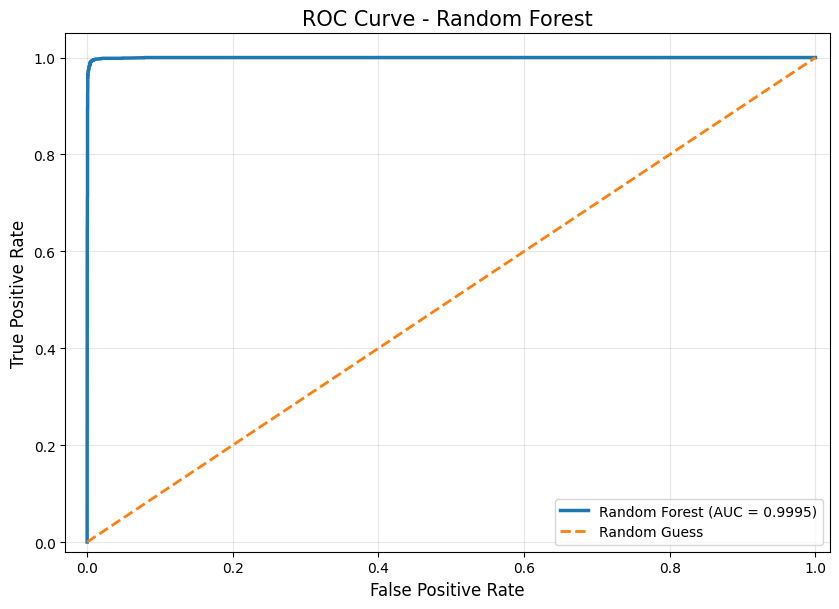


Feature Importance Method: Native


,Feature,Importance
0,punc_lt,0.223743
1,punc_gt,0.101640
2,combo_gt_lt,0.094830
3,symbols_ratio,0.079263
4,tag_script,0.078401
5,punc_dquote,0.067184
6,punc_lparen,0.029524
7,readability,0.029255
8,punc_amp,0.026102
9,punc_comma,0.021884


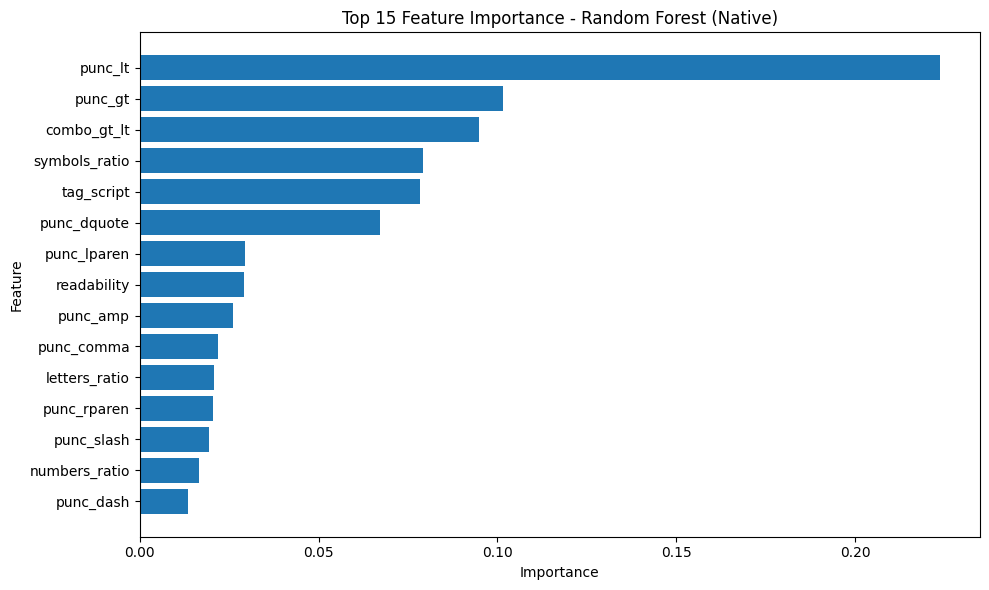


MODEL: KNN

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5589,24
Actual Positive (1),33,1916



Performance:
Execution time (sec): 1.4681
RAM peak (MB):        405.17
CPU peak (%):         118.90


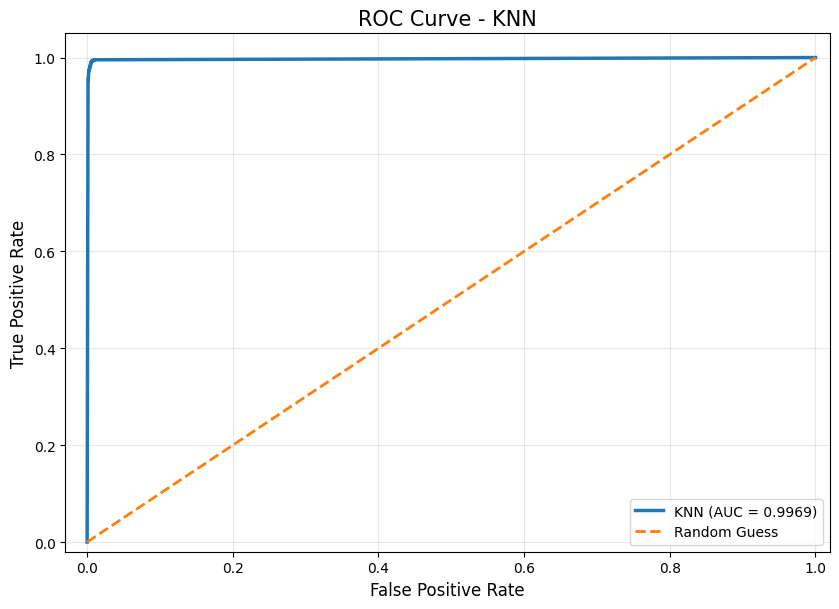


Feature Importance Method: Permutation


,Feature,Importance
0,punc_space,0.032214
1,punc_eq,0.027281
2,readability,0.003690
3,mth_search,0.001349
4,punc_dot,0.001217
5,punc_colon,0.001190
6,punc_lt,0.001071
7,punc_gt,0.000979
8,punc_dquote,0.000965
9,punc_comma,0.000952


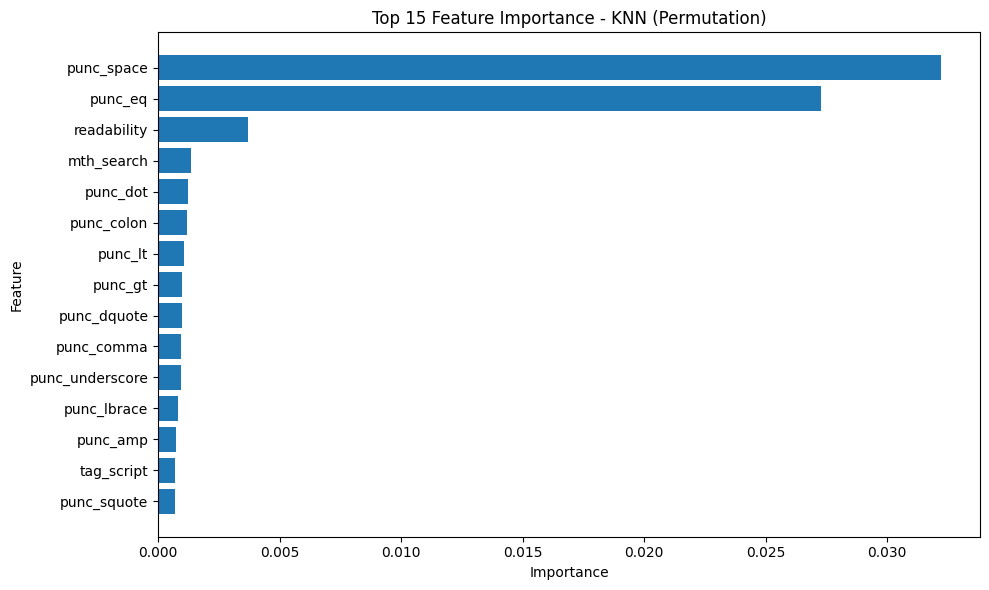


MODEL: SVM Poly

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5584,29
Actual Positive (1),14,1935



Performance:
Execution time (sec): 1.8687
RAM peak (MB):        477.01
CPU peak (%):         119.00


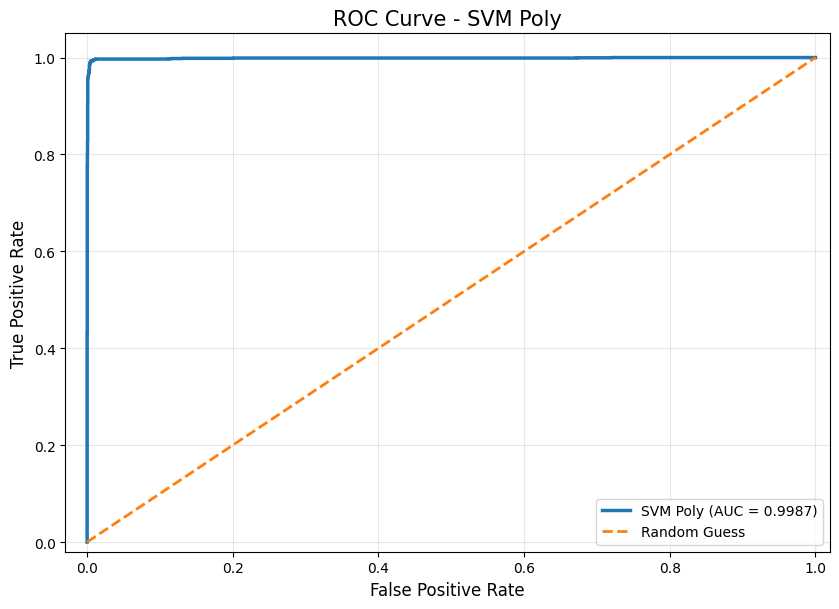


Feature Importance Method: Permutation


,Feature,Importance
0,punc_amp,0.203623
1,punc_eq,0.154218
2,punc_space,0.103994
3,punc_gt,0.032346
4,readability,0.029344
5,punc_comma,0.010540
6,punc_dot,0.004351
7,punc_dquote,0.003742
8,punc_bslash,0.003570
9,punc_rparen,0.003518


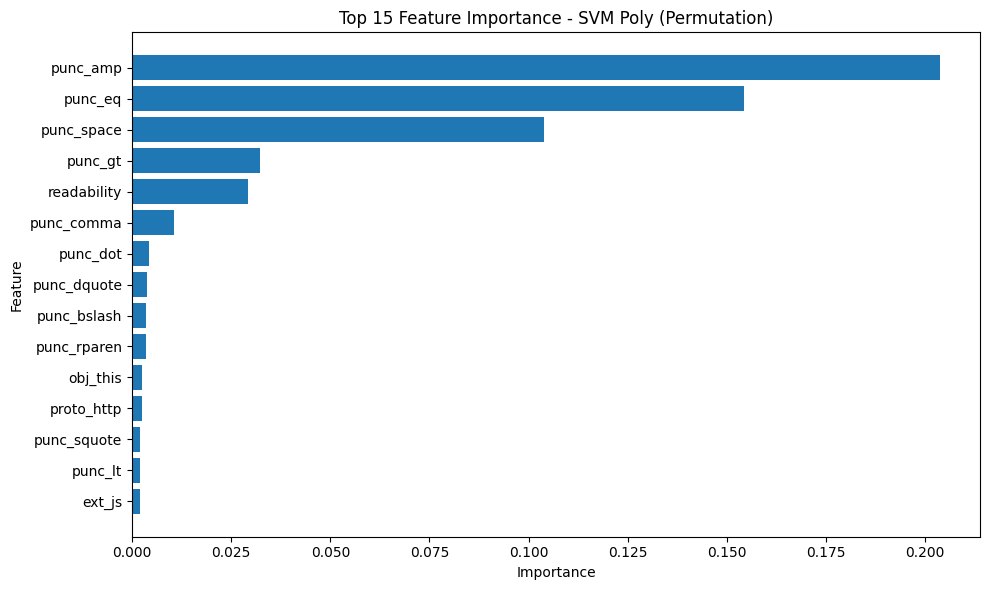


MODEL: SVM Linear

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5571,42
Actual Positive (1),53,1896



Performance:
Execution time (sec): 0.7297
RAM peak (MB):        455.00
CPU peak (%):         118.00


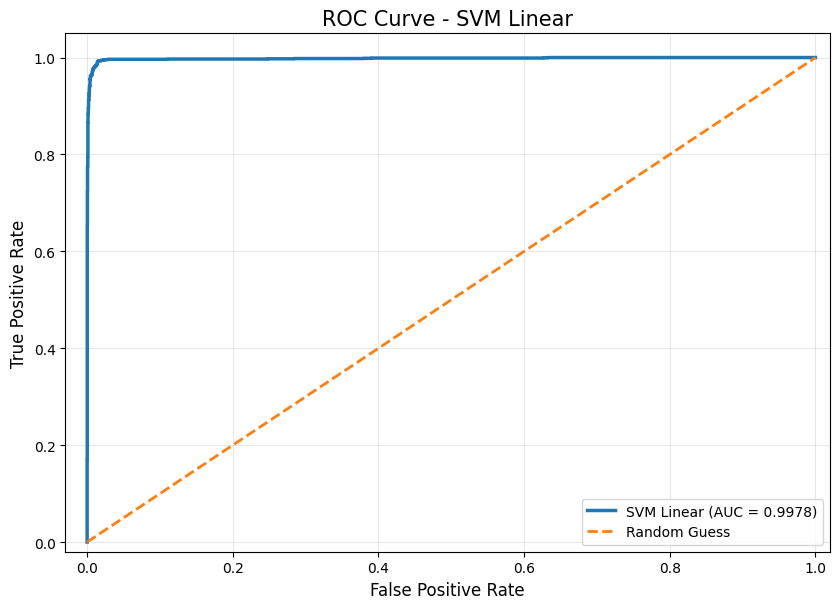


Feature Importance Method: Permutation


,Feature,Importance
0,punc_lt,0.051217
1,punc_comma,0.005104
2,punc_amp,0.004774
3,punc_lbrace,0.003518
4,readability,0.002989
5,punc_gt,0.002407
6,tag_script,0.002301
7,mth_fromcharcode,0.002156
8,punc_space,0.001865
9,punc_colon,0.001851


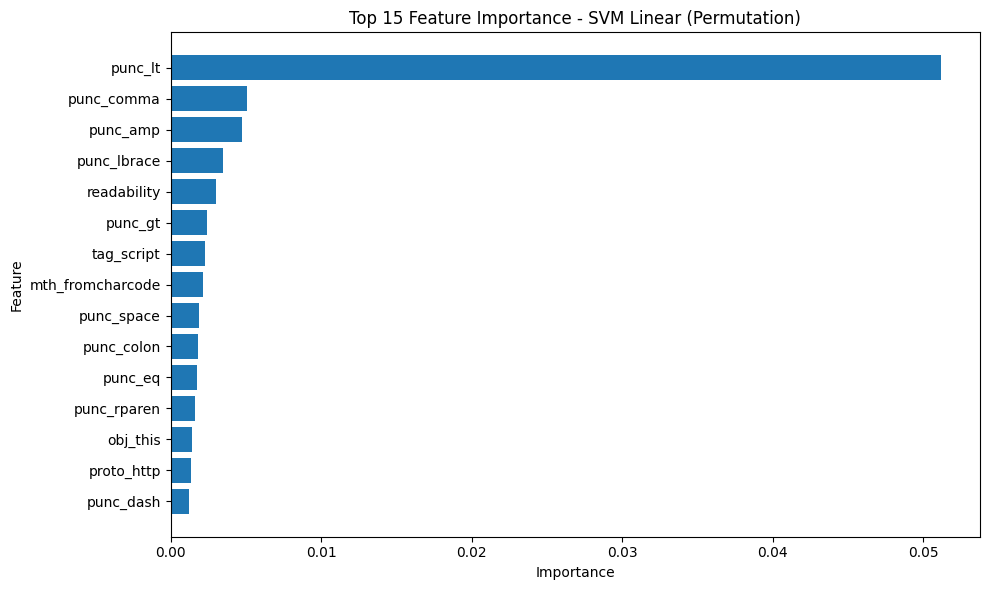


SUMMARY RESULTS


,Model,Accuracy,Precision,Sensitivity,Specificity,AUC,Execution Time (sec),RAM Peak (MB),CPU Peak (%),Importance Method
0,SVM Poly,0.9943,0.9852,0.9928,0.9948,0.9987,1.8687,477.0117,119.0,Permutation
1,Random Forest,0.9939,0.9852,0.9913,0.9948,0.9995,1.3154,396.6641,119.0,Native
2,KNN,0.9925,0.9876,0.9831,0.9957,0.9969,1.4681,405.1719,118.9,Permutation
3,SVM Linear,0.9874,0.9783,0.9728,0.9925,0.9978,0.7297,455.0039,118.0,Permutation



TOP 10 IMPORTANT FEATURES

Top 10 - Random Forest


,Feature,Importance
0,punc_lt,0.223743
1,punc_gt,0.101640
2,combo_gt_lt,0.094830
3,symbols_ratio,0.079263
4,tag_script,0.078401
5,punc_dquote,0.067184
6,punc_lparen,0.029524
7,readability,0.029255
8,punc_amp,0.026102
9,punc_comma,0.021884



Top 10 - KNN


,Feature,Importance
0,punc_space,0.032214
1,punc_eq,0.027281
2,readability,0.003690
3,mth_search,0.001349
4,punc_dot,0.001217
5,punc_colon,0.001190
6,punc_lt,0.001071
7,punc_gt,0.000979
8,punc_dquote,0.000965
9,punc_comma,0.000952



Top 10 - SVM Poly


,Feature,Importance
0,punc_amp,0.203623
1,punc_eq,0.154218
2,punc_space,0.103994
3,punc_gt,0.032346
4,readability,0.029344
5,punc_comma,0.010540
6,punc_dot,0.004351
7,punc_dquote,0.003742
8,punc_bslash,0.003570
9,punc_rparen,0.003518



Top 10 - SVM Linear


,Feature,Importance
0,punc_lt,0.051217
1,punc_comma,0.005104
2,punc_amp,0.004774
3,punc_lbrace,0.003518
4,readability,0.002989
5,punc_gt,0.002407
6,tag_script,0.002301
7,mth_fromcharcode,0.002156
8,punc_space,0.001865
9,punc_colon,0.001851


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import threading
import os
import psutil
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    auc
)
from sklearn.inspection import permutation_importance

# =======================
# Display helper
# =======================
def safe_display(obj):
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

# =========================
# 1. Đọc dữ liệu
# =========================
train_path = "/content/drive/MyDrive/ATPM/train.csv"
test_path = "/content/drive/MyDrive/ATPM/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# =========================
# 2. Tách X, y
# =========================
if "label" in train_df.columns and "label" in test_df.columns:
    X_train = train_df.drop(columns=["label"])
    y_train = train_df["label"]

    X_test = test_df.drop(columns=["label"])
    y_test = test_df["label"]
else:
    X_train = train_df.iloc[:, :-1]
    y_train = train_df.iloc[:, -1]

    X_test = test_df.iloc[:, :-1]
    y_test = test_df.iloc[:, -1]

feature_names = X_train.columns.tolist()

# =========================
# 3. Model
# =========================
models = {
    "Random Forest": RandomForestClassifier(
        max_depth=20,
        min_samples_split=2,
        n_estimators=60,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),
    "SVM Poly": SVC(
        kernel="poly",
        C=10,
        degree=3,
        gamma="scale",
        probability=False
    ),
    "SVM Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1,
            max_iter=5000,
            random_state=42
        ))
    ])
}

# =========================
# Helper
# =========================
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)

def plot_single_roc(y_true, y_score, model_name):
    if len(np.unique(y_true)) != 2:
        print(f"Không thể vẽ ROC cho {model_name}")
        return np.nan

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8.5, 6.2))
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curve - {model_name}", fontsize=15)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)

    plt.xlim(-0.03, 1.02)
    plt.ylim(-0.02, 1.05)

    plt.tight_layout()
    plt.show()

    return roc_auc

def get_feature_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        method = "Native"

    elif hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 1:
            importances = np.abs(coef)
        else:
            importances = np.mean(np.abs(coef), axis=0)
        method = "Native"

    else:
        perm = permutation_importance(
            model,
            X,
            y,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )
        importances = perm.importances_mean
        method = "Permutation"

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    return imp_df, method

def plot_top_features(imp_df, model_name, method_name, top_n=15):
    top_df = imp_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Feature Importance - {model_name} ({method_name})")
    plt.tight_layout()
    plt.show()

# =========================
# Performance monitor
# =========================
class ResourceMonitor:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.running = False
        self.thread = None
        self.cpu_peak = 0.0
        self.ram_peak_mb = 0.0

    def _monitor(self):
        # Prime cpu_percent để lần đo sau có ý nghĩa
        self.process.cpu_percent(interval=None)

        while self.running:
            try:
                cpu = self.process.cpu_percent(interval=None)
                ram_mb = self.process.memory_info().rss / (1024 ** 2)

                if cpu > self.cpu_peak:
                    self.cpu_peak = cpu
                if ram_mb > self.ram_peak_mb:
                    self.ram_peak_mb = ram_mb

                time.sleep(self.interval)
            except Exception:
                break

    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._monitor, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        if self.thread is not None:
            self.thread.join(timeout=1)

def evaluate_with_monitor(model, X_train, y_train, X_test):
    monitor = ResourceMonitor(interval=0.05)

    t0 = time.perf_counter()
    monitor.start()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    monitor.stop()
    t1 = time.perf_counter()
    y_score = get_scores(model, X_test)

    exec_time = t1 - t0

    return {
        "y_pred": y_pred,
        "y_score": y_score,
        "exec_time_sec": exec_time,
        "cpu_peak_percent": monitor.cpu_peak,
        "ram_peak_mb": monitor.ram_peak_mb
    }

# =========================
# Train + Evaluate
# =========================
results = []
all_importance_tables = {}

for name, model in models.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    # ==========================================================
    # Chỉ đo thời gian / RAM / CPU cho fit + predict + score
    # KHÔNG bao gồm feature importance
    # ==========================================================
    perf_out = evaluate_with_monitor(model, X_train, y_train, X_test)

    y_pred = perf_out["y_pred"]
    y_score = perf_out["y_score"]
    exec_time_sec = perf_out["exec_time_sec"]
    cpu_peak_percent = perf_out["cpu_peak_percent"]
    ram_peak_mb = perf_out["ram_peak_mb"]

    # ===== Metrics =====
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    else:
        specificity = 0

    # ===== Confusion Matrix =====
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Negative (0)", "Actual Positive (1)"][:cm.shape[0]],
        columns=["Predicted Negative (0)", "Predicted Positive (1)"][:cm.shape[1]]
    )

    print("\nConfusion Matrix:")
    safe_display(cm_df)

    print("\nPerformance:")
    print(f"Execution time (sec): {exec_time_sec:.4f}")
    print(f"RAM peak (MB):        {ram_peak_mb:.2f}")
    print(f"CPU peak (%):         {cpu_peak_percent:.2f}")

    # ===== ROC =====
    roc_auc = plot_single_roc(y_test, y_score, name)

    # ===== Feature Importance =====
    # Phần này KHÔNG tính vào execution time / RAM / CPU ở trên
    imp_df, imp_method = get_feature_importance(
        model,
        X_test,
        y_test,
        feature_names
    )

    all_importance_tables[name] = imp_df.copy()

    print(f"\nFeature Importance Method: {imp_method}")
    safe_display(imp_df.head(15).round(6))

    plot_top_features(imp_df, name, imp_method)

    # ===== Save =====
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": roc_auc,
        "Execution Time (sec)": exec_time_sec,
        "RAM Peak (MB)": ram_peak_mb,
        "CPU Peak (%)": cpu_peak_percent,
        "Importance Method": imp_method
    })

# =========================
# SUMMARY
# =========================
print("\n" + "=" * 70)
print("SUMMARY RESULTS")
print("=" * 70)

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

safe_display(results_df)

# =========================
# Top importance
# =========================
print("\n" + "=" * 70)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 70)

for model_name, imp_df in all_importance_tables.items():
    print(f"\nTop 10 - {model_name}")
    safe_display(imp_df.head(10).round(6))


MODEL: Random Forest

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),0,0
Actual Positive (1),50,784



Performance:
Execution time (sec): 1.2659
RAM peak (MB):        458.95
CPU peak (%):         119.00
Không thể vẽ ROC cho Random Forest

Feature Importance Method: Native


,Feature,Importance
0,punc_lt,0.223743
1,punc_gt,0.101640
2,combo_gt_lt,0.094830
3,symbols_ratio,0.079263
4,tag_script,0.078401
5,punc_dquote,0.067184
6,punc_lparen,0.029524
7,readability,0.029255
8,punc_amp,0.026102
9,punc_comma,0.021884


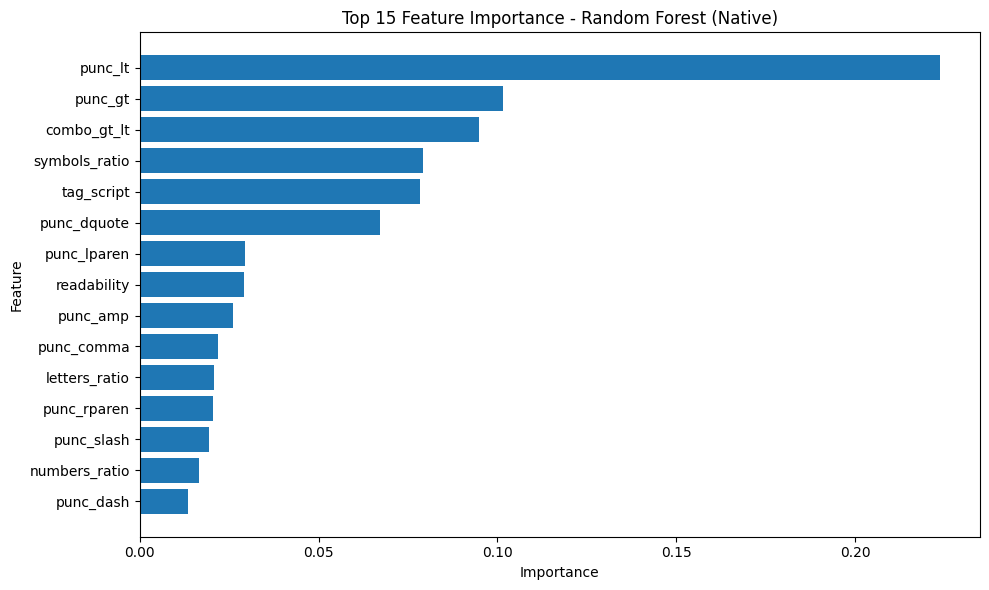


MODEL: KNN

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),0,0
Actual Positive (1),70,764



Performance:
Execution time (sec): 0.2027
RAM peak (MB):        458.95
CPU peak (%):         118.90
Không thể vẽ ROC cho KNN

Feature Importance Method: Permutation


,Feature,Importance
0,readability,0.052998
1,punc_space,0.010911
2,attr_cookie,0.007554
3,punc_eq,0.005036
4,letters_ratio,0.004317
5,punc_at,0.002878
6,mth_fromcharcode,0.002278
7,obj_document,0.002158
8,punc_plus,0.000959
9,punc_dash,0.000719


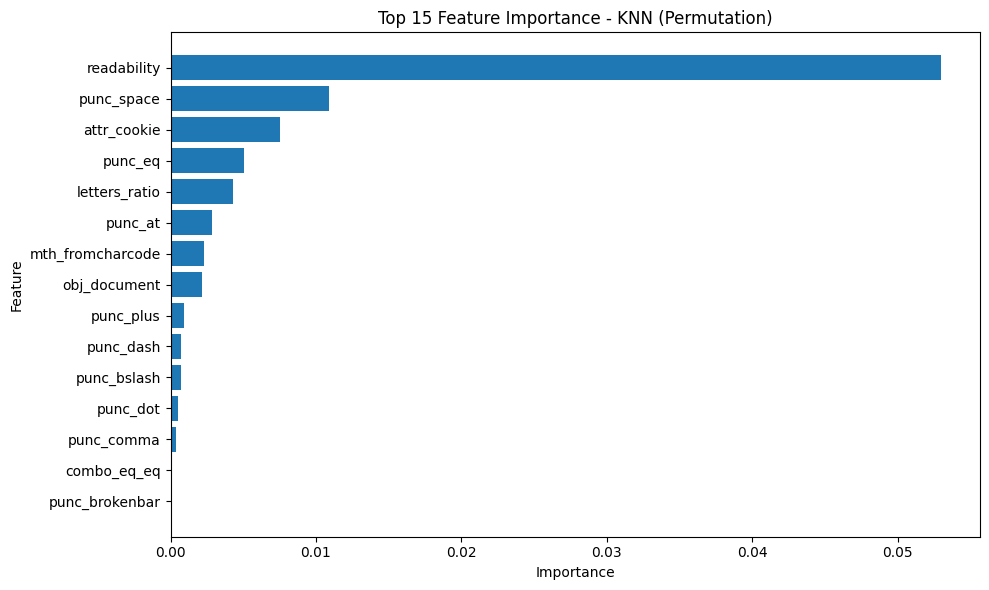


MODEL: SVM Poly

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),0,0
Actual Positive (1),141,693



Performance:
Execution time (sec): 2.3346
RAM peak (MB):        458.95
CPU peak (%):         115.30
Không thể vẽ ROC cho SVM Poly

Feature Importance Method: Permutation


,Feature,Importance
0,proto_http,0.020264
1,attr_cookie,0.008513
2,tag_img,0.007794
3,tag_script,0.005396
4,punc_slash,0.005396
5,symbols_ratio,0.004077
6,punc_space,0.003717
7,evt_onload,0.001918
8,punc_colon,0.001439
9,tag_div,0.001319


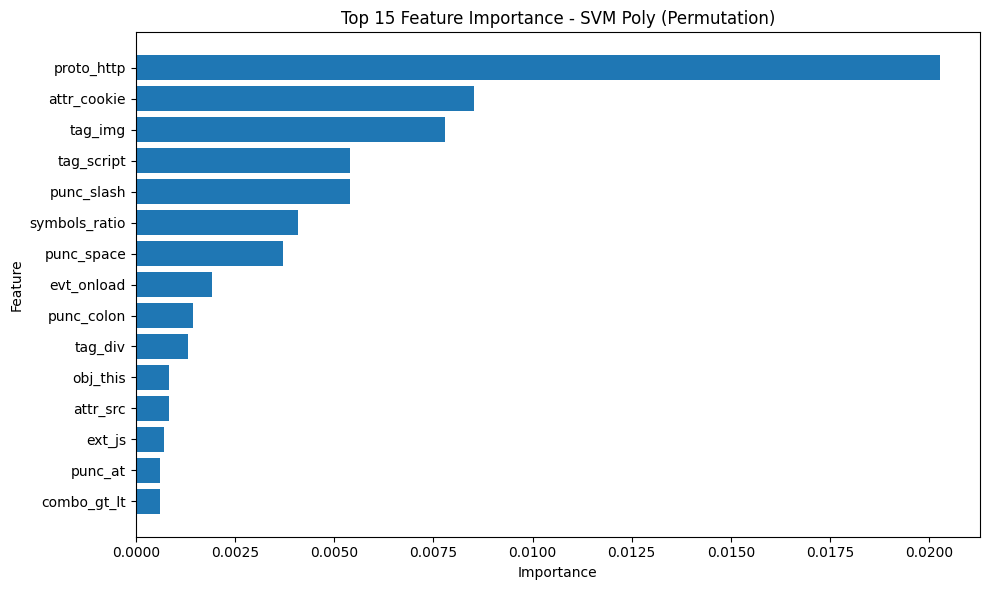


MODEL: SVM Linear

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),0,0
Actual Positive (1),68,766



Performance:
Execution time (sec): 0.5067
RAM peak (MB):        458.95
CPU peak (%):         99.40
Không thể vẽ ROC cho SVM Linear

Feature Importance Method: Permutation


,Feature,Importance
0,letters_ratio,0.027218
1,attr_cookie,0.022542
2,punc_space,0.017026
3,tag_script,0.015827
4,readability,0.011631
5,punc_eq,0.011391
6,obj_document,0.009832
7,symbols_ratio,0.008633
8,tag_img,0.008393
9,proto_http,0.007794


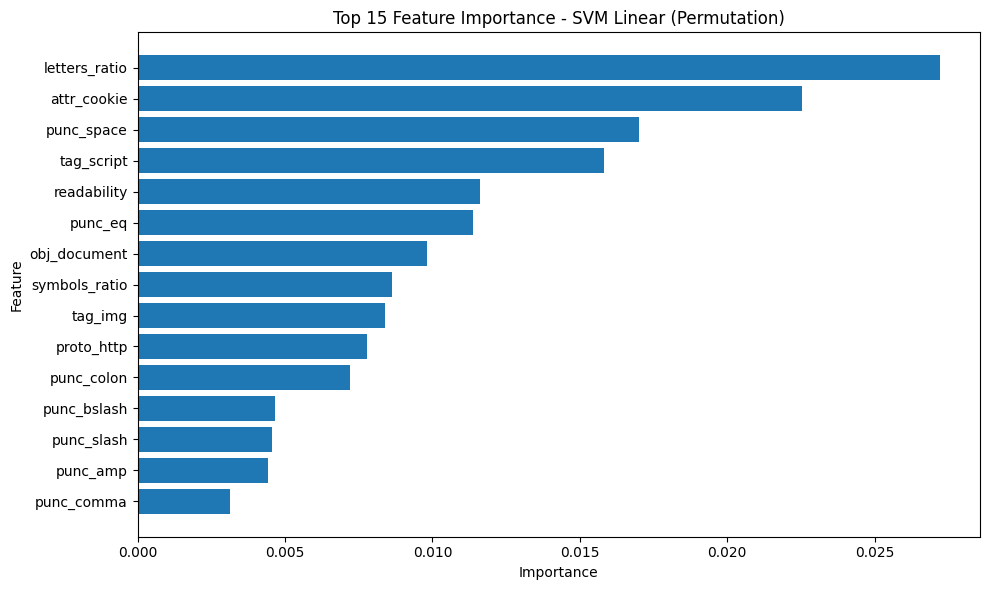


SUMMARY RESULTS


,Model,Accuracy,Precision,Sensitivity,Specificity,AUC,Execution Time (sec),RAM Peak (MB),CPU Peak (%),Importance Method
0,Random Forest,0.9400,1.0,0.9400,0,NaN,1.2659,458.9453,119.0,Native
1,SVM Linear,0.9185,1.0,0.9185,0,NaN,0.5067,458.9453,99.4,Permutation
2,KNN,0.9161,1.0,0.9161,0,NaN,0.2027,458.9453,118.9,Permutation
3,SVM Poly,0.8309,1.0,0.8309,0,NaN,2.3346,458.9453,115.3,Permutation



TOP 10 IMPORTANT FEATURES

Top 10 - Random Forest


,Feature,Importance
0,punc_lt,0.223743
1,punc_gt,0.101640
2,combo_gt_lt,0.094830
3,symbols_ratio,0.079263
4,tag_script,0.078401
5,punc_dquote,0.067184
6,punc_lparen,0.029524
7,readability,0.029255
8,punc_amp,0.026102
9,punc_comma,0.021884



Top 10 - KNN


,Feature,Importance
0,readability,0.052998
1,punc_space,0.010911
2,attr_cookie,0.007554
3,punc_eq,0.005036
4,letters_ratio,0.004317
5,punc_at,0.002878
6,mth_fromcharcode,0.002278
7,obj_document,0.002158
8,punc_plus,0.000959
9,punc_dash,0.000719



Top 10 - SVM Poly


,Feature,Importance
0,proto_http,0.020264
1,attr_cookie,0.008513
2,tag_img,0.007794
3,tag_script,0.005396
4,punc_slash,0.005396
5,symbols_ratio,0.004077
6,punc_space,0.003717
7,evt_onload,0.001918
8,punc_colon,0.001439
9,tag_div,0.001319



Top 10 - SVM Linear


,Feature,Importance
0,letters_ratio,0.027218
1,attr_cookie,0.022542
2,punc_space,0.017026
3,tag_script,0.015827
4,readability,0.011631
5,punc_eq,0.011391
6,obj_document,0.009832
7,symbols_ratio,0.008633
8,tag_img,0.008393
9,proto_http,0.007794


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import threading
import os
import psutil
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    auc
)
from sklearn.inspection import permutation_importance

# =======================
# Display helper
# =======================
def safe_display(obj):
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

# =========================
# 1. Đọc dữ liệu
# =========================
train_path = "/content/drive/MyDrive/ATPM/train.csv"
test_path = "/content/drive/MyDrive/ATPM/realCase.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# =========================
# 2. Tách X, y
# =========================
if "label" in train_df.columns and "label" in test_df.columns:
    X_train = train_df.drop(columns=["label"])
    y_train = train_df["label"]

    X_test = test_df.drop(columns=["label"])
    y_test = test_df["label"]
else:
    X_train = train_df.iloc[:, :-1]
    y_train = train_df.iloc[:, -1]

    X_test = test_df.iloc[:, :-1]
    y_test = test_df.iloc[:, -1]

feature_names = X_train.columns.tolist()

# =========================
# 3. Model
# =========================
models = {
    "Random Forest": RandomForestClassifier(
        max_depth=20,
        min_samples_split=2,
        n_estimators=60,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),
    "SVM Poly": SVC(
        kernel="poly",
        C=10,
        degree=3,
        gamma="scale",
        probability=False
    ),
    "SVM Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1,
            max_iter=5000,
            random_state=42
        ))
    ])
}

# =========================
# Helper
# =========================
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)

def plot_single_roc(y_true, y_score, model_name):
    if len(np.unique(y_true)) != 2:
        print(f"Không thể vẽ ROC cho {model_name}")
        return np.nan

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8.5, 6.2))
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curve - {model_name}", fontsize=15)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)

    plt.xlim(-0.03, 1.02)
    plt.ylim(-0.02, 1.05)

    plt.tight_layout()
    plt.show()

    return roc_auc

def get_feature_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        method = "Native"

    elif hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 1:
            importances = np.abs(coef)
        else:
            importances = np.mean(np.abs(coef), axis=0)
        method = "Native"

    else:
        perm = permutation_importance(
            model,
            X,
            y,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )
        importances = perm.importances_mean
        method = "Permutation"

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    return imp_df, method

def plot_top_features(imp_df, model_name, method_name, top_n=15):
    top_df = imp_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Feature Importance - {model_name} ({method_name})")
    plt.tight_layout()
    plt.show()

# =========================
# Performance monitor
# =========================
class ResourceMonitor:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.running = False
        self.thread = None
        self.cpu_peak = 0.0
        self.ram_peak_mb = 0.0

    def _monitor(self):
        # Prime cpu_percent để lần đo sau có ý nghĩa
        self.process.cpu_percent(interval=None)

        while self.running:
            try:
                cpu = self.process.cpu_percent(interval=None)
                ram_mb = self.process.memory_info().rss / (1024 ** 2)

                if cpu > self.cpu_peak:
                    self.cpu_peak = cpu
                if ram_mb > self.ram_peak_mb:
                    self.ram_peak_mb = ram_mb

                time.sleep(self.interval)
            except Exception:
                break

    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._monitor, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        if self.thread is not None:
            self.thread.join(timeout=1)

def evaluate_with_monitor(model, X_train, y_train, X_test):
    monitor = ResourceMonitor(interval=0.05)

    t0 = time.perf_counter()
    monitor.start()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    monitor.stop()
    t1 = time.perf_counter()
    y_score = get_scores(model, X_test)

    exec_time = t1 - t0

    return {
        "y_pred": y_pred,
        "y_score": y_score,
        "exec_time_sec": exec_time,
        "cpu_peak_percent": monitor.cpu_peak,
        "ram_peak_mb": monitor.ram_peak_mb
    }

# =========================
# Train + Evaluate
# =========================
results = []
all_importance_tables = {}

for name, model in models.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    # ==========================================================
    # Chỉ đo thời gian / RAM / CPU cho fit + predict + score
    # KHÔNG bao gồm feature importance
    # ==========================================================
    perf_out = evaluate_with_monitor(model, X_train, y_train, X_test)

    y_pred = perf_out["y_pred"]
    y_score = perf_out["y_score"]
    exec_time_sec = perf_out["exec_time_sec"]
    cpu_peak_percent = perf_out["cpu_peak_percent"]
    ram_peak_mb = perf_out["ram_peak_mb"]

    # ===== Metrics =====
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    else:
        specificity = 0

    # ===== Confusion Matrix =====
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Negative (0)", "Actual Positive (1)"][:cm.shape[0]],
        columns=["Predicted Negative (0)", "Predicted Positive (1)"][:cm.shape[1]]
    )

    print("\nConfusion Matrix:")
    safe_display(cm_df)

    print("\nPerformance:")
    print(f"Execution time (sec): {exec_time_sec:.4f}")
    print(f"RAM peak (MB):        {ram_peak_mb:.2f}")
    print(f"CPU peak (%):         {cpu_peak_percent:.2f}")

    # ===== ROC =====
    roc_auc = plot_single_roc(y_test, y_score, name)

    # ===== Feature Importance =====
    # Phần này KHÔNG tính vào execution time / RAM / CPU ở trên
    imp_df, imp_method = get_feature_importance(
        model,
        X_test,
        y_test,
        feature_names
    )

    all_importance_tables[name] = imp_df.copy()

    print(f"\nFeature Importance Method: {imp_method}")
    safe_display(imp_df.head(15).round(6))

    plot_top_features(imp_df, name, imp_method)

    # ===== Save =====
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": roc_auc,
        "Execution Time (sec)": exec_time_sec,
        "RAM Peak (MB)": ram_peak_mb,
        "CPU Peak (%)": cpu_peak_percent,
        "Importance Method": imp_method
    })

# =========================
# SUMMARY
# =========================
print("\n" + "=" * 70)
print("SUMMARY RESULTS")
print("=" * 70)

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

safe_display(results_df)

# =========================
# Top importance
# =========================
print("\n" + "=" * 70)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 70)

for model_name, imp_df in all_importance_tables.items():
    print(f"\nTop 10 - {model_name}")
    safe_display(imp_df.head(10).round(6))

In [2]:
# ======================================
# CONFIG + DATA LOADING
# ======================================

import os
import time
import threading
import numpy as np
import pandas as pd
import psutil

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/train.csv"

TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

ENCODING = "latin1"

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 10
RANDOM_STATE = 42
SCORING = "f1"

# ------------------------
# LOAD DATA
# ------------------------
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, encoding=ENCODING)
assert TARGET_COLUMN in df.columns, f"Missing target column: {TARGET_COLUMN}"

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print("Shape:", X.shape)
print("Class distribution:")
print(y.value_counts(normalize=False))
print("\nClass ratio:")
print(y.value_counts(normalize=True))


# ======================================
# HELPERS
# ======================================

class ResourceMonitor:
    """
    Theo dõi peak RAM và peak CPU của process hiện tại
    trong lúc chạy GridSearchCV.fit(...)
    """
    def __init__(self, sample_interval=0.05):
        self.sample_interval = sample_interval
        self.process = psutil.Process(os.getpid())
        self.stop_event = threading.Event()
        self.thread = None
        self.peak_ram_mb = 0.0
        self.peak_cpu_pct = 0.0

    def _run(self):
        self.process.cpu_percent(interval=None)

        while not self.stop_event.is_set():
            try:
                ram_mb = self.process.memory_info().rss / (1024 ** 2)
                cpu_pct = self.process.cpu_percent(interval=None)

                self.peak_ram_mb = max(self.peak_ram_mb, ram_mb)
                self.peak_cpu_pct = max(self.peak_cpu_pct, cpu_pct)
            except Exception:
                pass

            time.sleep(self.sample_interval)

    def start(self):
        self.thread = threading.Thread(target=self._run, daemon=True)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        if self.thread is not None:
            self.thread.join()


def fit_grid_with_resource_monitor(grid, X_fit, y_fit):
    """
    Chạy grid.fit(X, y) và đo:
    - thời gian
    - peak RAM
    - peak CPU
    """
    monitor = ResourceMonitor(sample_interval=0.05)

    t0 = time.perf_counter()
    monitor.start()
    grid.fit(X_fit, y_fit)
    monitor.stop()
    t1 = time.perf_counter()

    return {
        "grid": grid,
        "fit_time_sec": t1 - t0,
        "peak_ram_mb": monitor.peak_ram_mb,
        "peak_cpu_pct": monitor.peak_cpu_pct
    }


def compute_binary_metrics(y_true, y_pred):
    """
    Tính metrics nhị phân với labels = [0, 1]
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ConfusionMatrix": cm
    }


def make_confusion_matrix_table(cm):
    """
    Format confusion matrix dạng bảng đẹp như hình:
                        Predicted Negative (0)   Predicted Positive (1)
    Actual Negative (0)           TN                       FP
    Actual Positive (1)           FN                       TP
    """
    tn, fp, fn, tp = cm.ravel()

    cm_table = pd.DataFrame(
        {
            "Predicted Negative (0)": [tn, fn],
            "Predicted Positive (1)": [fp, tp]
        },
        index=["Actual Negative (0)", "Actual Positive (1)"]
    )

    return cm_table


# ================================
# GRID SEARCH FOR HYPERPARAMETERS
# ================================

print("\n" + "=" * 80)
print("RUNNING GRID SEARCH")
print("=" * 80)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "SVM Linear": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },

    "SVM Poly": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="poly",
                class_weight="balanced"
            ))
        ]),
        "params": {
            "clf__C": [0.01, 1, 10, 100],
            "clf__degree": [2, 3],
            "clf__gamma": ["scale", "auto"]
        }
    },

    "KNN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [60, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 3, 5]
        }
    }
}

best_models = {}
summary_rows = []
confusion_tables = {}

for name, cfg in param_grids.items():

    print("\n" + "-" * 60)
    print(f"Grid Search: {name}")
    print("-" * 60)

    grid = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        verbose=1,
        refit=True
    )

    # =========================
    # 1) Grid Search + peak RAM/CPU
    # =========================
    gs_result = fit_grid_with_resource_monitor(grid, X, y)
    fitted_grid = gs_result["grid"]

    print(f"\nBest F1: {fitted_grid.best_score_:.4f}")
    print("Best Params:", fitted_grid.best_params_)
    print(f"Grid Search Time     : {gs_result['fit_time_sec']:.4f} s")
    print(f"Grid Search Peak RAM : {gs_result['peak_ram_mb']:.2f} MB")
    print(f"Grid Search Peak CPU : {gs_result['peak_cpu_pct']:.2f}%")

    best_model = fitted_grid.best_estimator_
    best_models[name] = best_model

    # =========================
    # 2) Out-of-Fold prediction cho best model
    # =========================
    y_pred_oof = cross_val_predict(
        estimator=clone(best_model),
        X=X,
        y=y,
        cv=cv,
        method="predict",
        n_jobs=1
    )

    # =========================
    # 3) Metrics từ OOF prediction
    # =========================
    metrics = compute_binary_metrics(y, y_pred_oof)
    cm = metrics["ConfusionMatrix"]

    cm_table = make_confusion_matrix_table(cm)
    confusion_tables[name] = cm_table

    print("\n" + "=" * 60)
    print(f"Model: {name}")
    print("=" * 60)
    print()
    print(cm_table)

    print("\nOOF METRICS")
    print(f"Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"Precision   : {metrics['Precision']:.4f}")
    print(f"Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"Specificity : {metrics['Specificity']:.4f}")

    # =========================
    # 4) Summary row
    # =========================
    summary_rows.append({
        "Model": name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"]
    })

print("\n" + "=" * 80)
print("GRID SEARCH DONE")
print("=" * 80)


# ======================================
# SUMMARY TABLE FOR 4 MODELS
# ======================================

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("SUMMARY RESULTS")
print("=" * 60)
print()

summary_display = summary_df[
    ["Model", "Accuracy", "Precision", "Sensitivity", "Specificity"]
].copy()

summary_display = summary_display.round(4)
print(summary_display)


# ======================================
# CONFUSION MATRIX TABLES
# ======================================

print("\n" + "=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

for model_name, cm_table in confusion_tables.items():
    print("\n" + "=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)
    print()
    print(cm_table)

DATA LOADED
Shape: (30248, 62)
Class distribution:
label
0    22452
1     7796
Name: count, dtype: int64

Class ratio:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

RUNNING GRID SEARCH

------------------------------------------------------------
Grid Search: SVM Linear
------------------------------------------------------------
Fitting 10 folds for each of 4 candidates, totalling 40 fits

Best F1: 0.9712
Best Params: {'clf__C': 1}
Grid Search Time     : 14.2064 s
Grid Search Peak RAM : 354.98 MB
Grid Search Peak CPU : 129.30%

Model: SVM Linear

                     Predicted Negative (0)  Predicted Positive (1)
Actual Negative (0)                   22172                     280
Actual Positive (1)                     172                    7624

OOF METRICS
Accuracy    : 0.9851
Precision   : 0.9646
Sensitivity : 0.9779
Specificity : 0.9875

------------------------------------------------------------
Grid Search: SVM Poly
---------------------------------------


MODEL: Random Forest

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5586,27
Actual Positive (1),18,1931



Performance:
Execution time (sec): 2.1748
RAM peak (MB):        400.52
CPU peak (%):         119.10


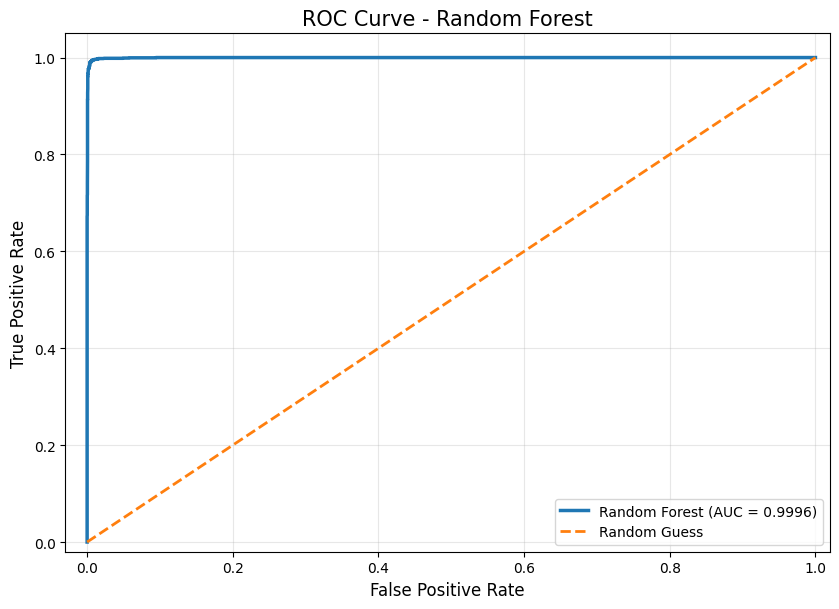


Feature Importance Method: Native


,Feature,Importance
0,punc_lt,0.209741
1,punc_gt,0.104152
2,combo_gt_lt,0.089787
3,punc_dquote,0.082521
4,tag_script,0.079577
5,symbols_ratio,0.058343
6,punc_lparen,0.041599
7,readability,0.030551
8,punc_amp,0.025281
9,punc_rparen,0.024273


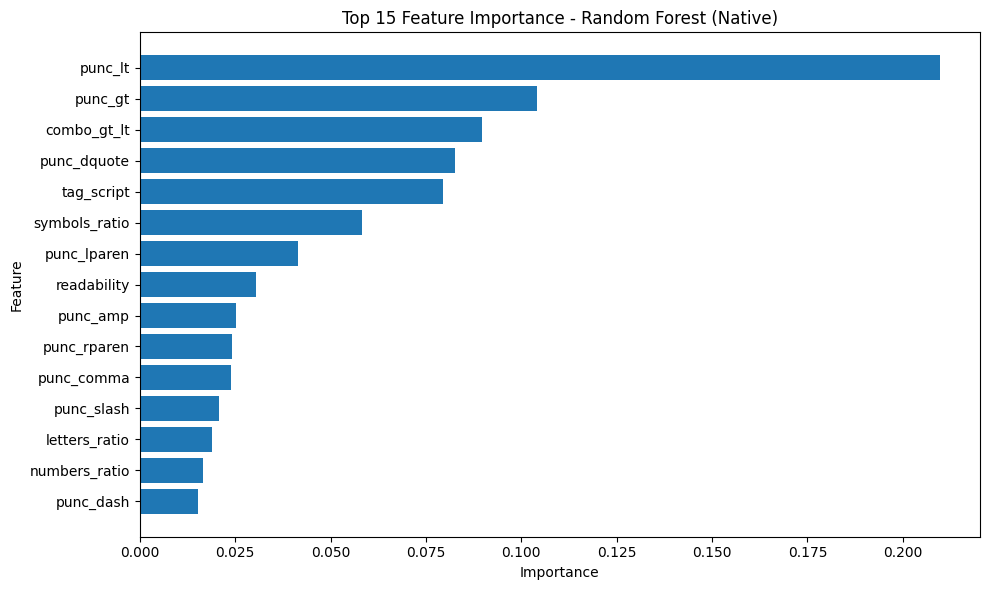


MODEL: KNN

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5588,25
Actual Positive (1),28,1921



Performance:
Execution time (sec): 1.4134
RAM peak (MB):        414.71
CPU peak (%):         119.30


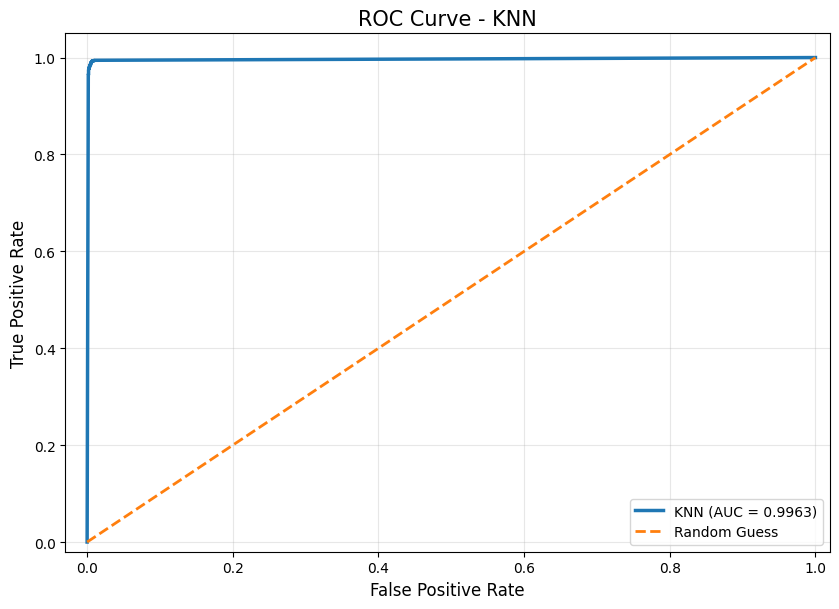


Feature Importance Method: Permutation


,Feature,Importance
0,punc_eq,0.034382
1,punc_space,0.032637
2,readability,0.005184
3,punc_colon,0.001494
4,mth_search,0.001203
5,punc_comma,0.001111
6,punc_dot,0.001005
7,tag_script,0.000939
8,proto_http,0.000912
9,punc_dquote,0.000873


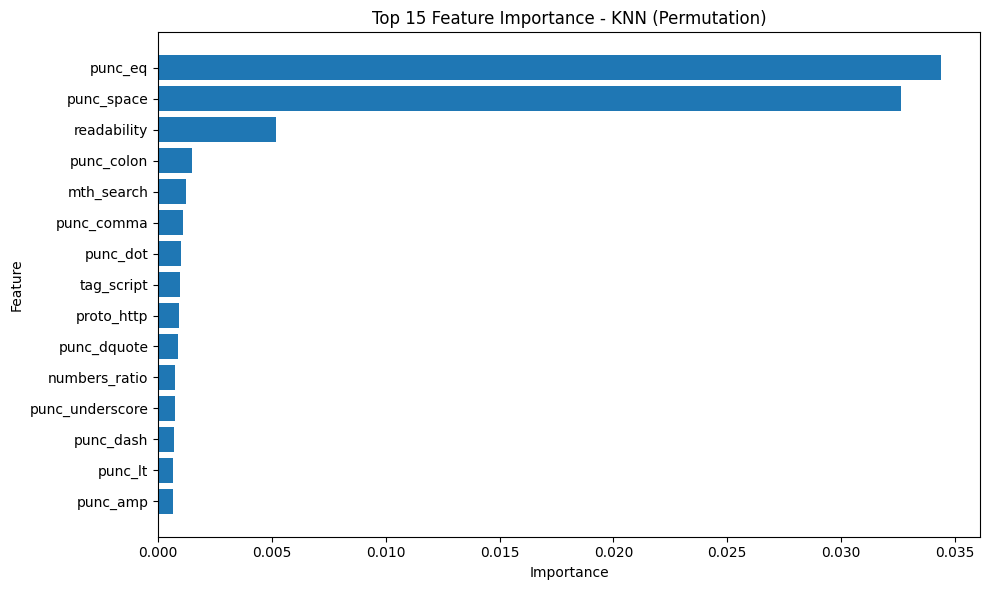


MODEL: SVM Poly

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5584,29
Actual Positive (1),14,1935



Performance:
Execution time (sec): 3.0947
RAM peak (MB):        482.57
CPU peak (%):         118.90


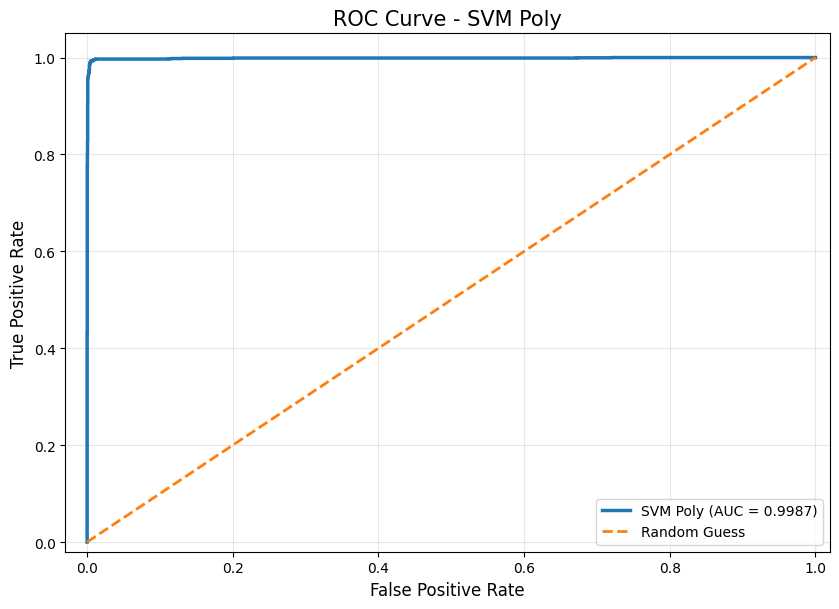


Feature Importance Method: Permutation


,Feature,Importance
0,punc_amp,0.203623
1,punc_eq,0.154218
2,punc_space,0.103994
3,punc_gt,0.032346
4,readability,0.029344
5,punc_comma,0.010540
6,punc_dot,0.004351
7,punc_dquote,0.003742
8,punc_bslash,0.003570
9,punc_rparen,0.003518


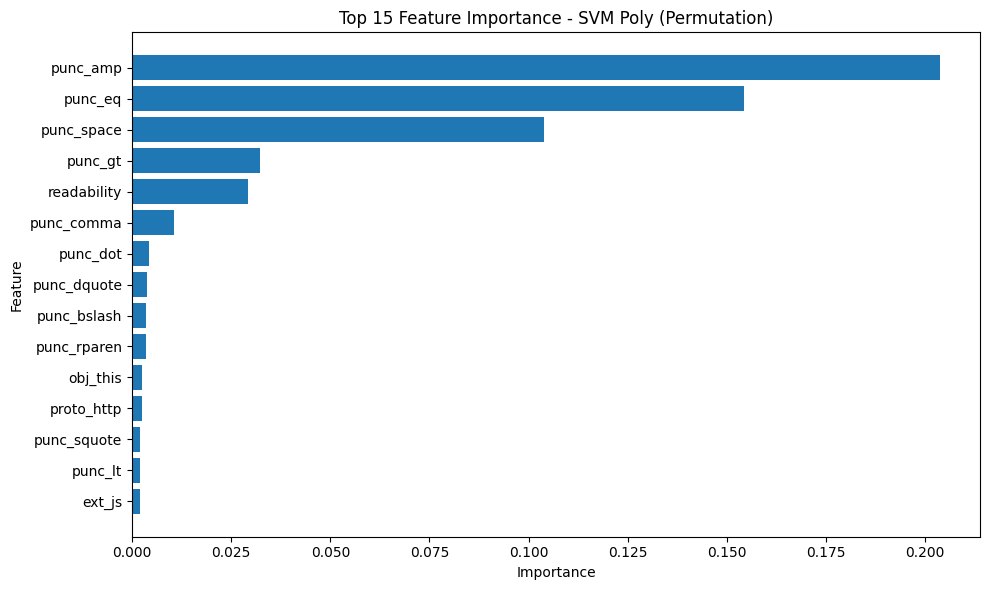


MODEL: SVM Linear

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5571,42
Actual Positive (1),53,1896



Performance:
Execution time (sec): 0.8236
RAM peak (MB):        458.61
CPU peak (%):         118.40


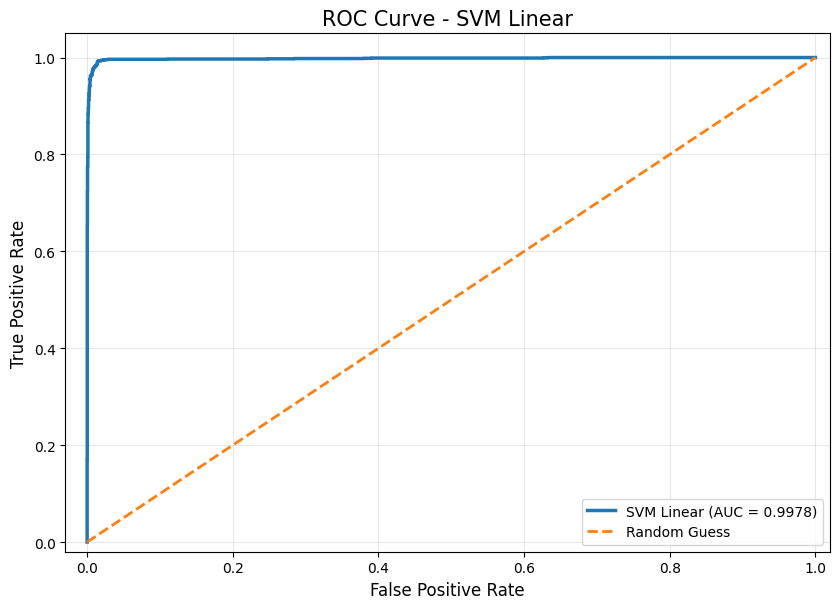


Feature Importance Method: Permutation


,Feature,Importance
0,punc_lt,0.051217
1,punc_comma,0.005104
2,punc_amp,0.004774
3,punc_lbrace,0.003518
4,readability,0.002989
5,punc_gt,0.002407
6,tag_script,0.002301
7,mth_fromcharcode,0.002156
8,punc_space,0.001865
9,punc_colon,0.001851


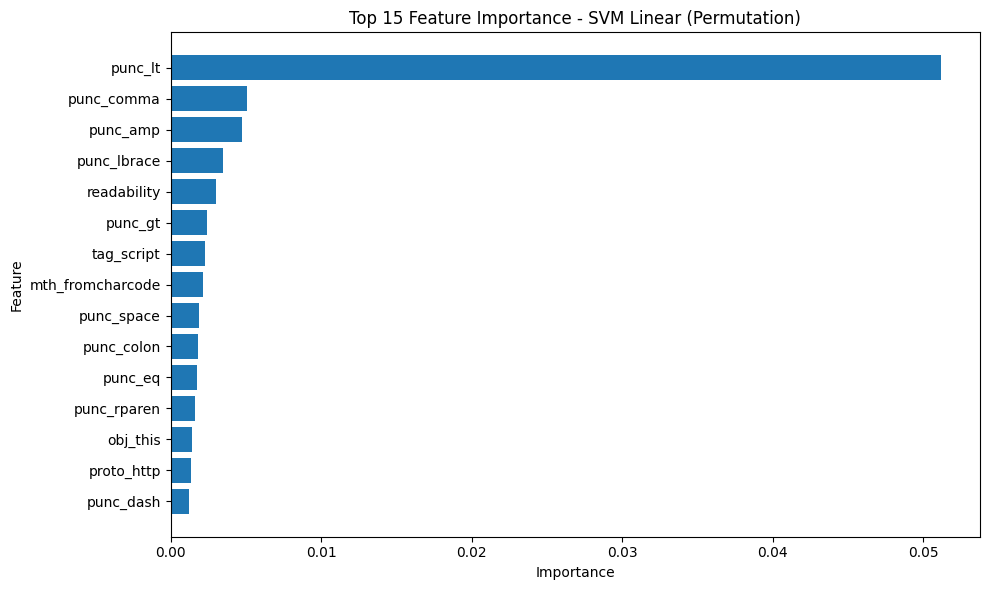


SUMMARY RESULTS


,Model,Accuracy,Precision,Sensitivity,Specificity,AUC,Execution Time (sec),RAM Peak (MB),CPU Peak (%),Importance Method
0,SVM Poly,0.9943,0.9852,0.9928,0.9948,0.9987,3.0947,482.5664,118.9,Permutation
1,Random Forest,0.9940,0.9862,0.9908,0.9952,0.9996,2.1748,400.5234,119.1,Native
2,KNN,0.9930,0.9872,0.9856,0.9955,0.9963,1.4134,414.7070,119.3,Permutation
3,SVM Linear,0.9874,0.9783,0.9728,0.9925,0.9978,0.8236,458.6094,118.4,Permutation



TOP 10 IMPORTANT FEATURES

Top 10 - Random Forest


,Feature,Importance
0,punc_lt,0.209741
1,punc_gt,0.104152
2,combo_gt_lt,0.089787
3,punc_dquote,0.082521
4,tag_script,0.079577
5,symbols_ratio,0.058343
6,punc_lparen,0.041599
7,readability,0.030551
8,punc_amp,0.025281
9,punc_rparen,0.024273



Top 10 - KNN


,Feature,Importance
0,punc_eq,0.034382
1,punc_space,0.032637
2,readability,0.005184
3,punc_colon,0.001494
4,mth_search,0.001203
5,punc_comma,0.001111
6,punc_dot,0.001005
7,tag_script,0.000939
8,proto_http,0.000912
9,punc_dquote,0.000873



Top 10 - SVM Poly


,Feature,Importance
0,punc_amp,0.203623
1,punc_eq,0.154218
2,punc_space,0.103994
3,punc_gt,0.032346
4,readability,0.029344
5,punc_comma,0.010540
6,punc_dot,0.004351
7,punc_dquote,0.003742
8,punc_bslash,0.003570
9,punc_rparen,0.003518



Top 10 - SVM Linear


,Feature,Importance
0,punc_lt,0.051217
1,punc_comma,0.005104
2,punc_amp,0.004774
3,punc_lbrace,0.003518
4,readability,0.002989
5,punc_gt,0.002407
6,tag_script,0.002301
7,mth_fromcharcode,0.002156
8,punc_space,0.001865
9,punc_colon,0.001851


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import threading
import os
import psutil
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    auc
)
from sklearn.inspection import permutation_importance

# =======================
# Display helper
# =======================
def safe_display(obj):
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

# =========================
# 1. Đọc dữ liệu
# =========================
train_path = "/content/drive/MyDrive/ATPM/train.csv"
test_path = "/content/drive/MyDrive/ATPM/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# =========================
# 2. Tách X, y
# =========================
if "label" in train_df.columns and "label" in test_df.columns:
    X_train = train_df.drop(columns=["label"])
    y_train = train_df["label"]

    X_test = test_df.drop(columns=["label"])
    y_test = test_df["label"]
else:
    X_train = train_df.iloc[:, :-1]
    y_train = train_df.iloc[:, -1]

    X_test = test_df.iloc[:, :-1]
    y_test = test_df.iloc[:, -1]

feature_names = X_train.columns.tolist()

# =========================
# 3. Model
# =========================
models = {
    "Random Forest": RandomForestClassifier(
        max_depth=20,
        min_samples_split=2,
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ),
    "SVM Poly": SVC(
        kernel="poly",
        C=10,
        degree=3,
        gamma="scale",
        probability=False
    ),
    "SVM Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1,
            max_iter=5000,
            random_state=42
        ))
    ])
}

# =========================
# Helper
# =========================
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)

def plot_single_roc(y_true, y_score, model_name):
    if len(np.unique(y_true)) != 2:
        print(f"Không thể vẽ ROC cho {model_name}")
        return np.nan

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8.5, 6.2))
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curve - {model_name}", fontsize=15)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)

    plt.xlim(-0.03, 1.02)
    plt.ylim(-0.02, 1.05)

    plt.tight_layout()
    plt.show()

    return roc_auc

def get_feature_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        method = "Native"

    elif hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 1:
            importances = np.abs(coef)
        else:
            importances = np.mean(np.abs(coef), axis=0)
        method = "Native"

    else:
        perm = permutation_importance(
            model,
            X,
            y,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )
        importances = perm.importances_mean
        method = "Permutation"

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    return imp_df, method

def plot_top_features(imp_df, model_name, method_name, top_n=15):
    top_df = imp_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Feature Importance - {model_name} ({method_name})")
    plt.tight_layout()
    plt.show()

# =========================
# Performance monitor
# =========================
class ResourceMonitor:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.running = False
        self.thread = None
        self.cpu_peak = 0.0
        self.ram_peak_mb = 0.0

    def _monitor(self):
        # Prime cpu_percent để lần đo sau có ý nghĩa
        self.process.cpu_percent(interval=None)

        while self.running:
            try:
                cpu = self.process.cpu_percent(interval=None)
                ram_mb = self.process.memory_info().rss / (1024 ** 2)

                if cpu > self.cpu_peak:
                    self.cpu_peak = cpu
                if ram_mb > self.ram_peak_mb:
                    self.ram_peak_mb = ram_mb

                time.sleep(self.interval)
            except Exception:
                break

    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._monitor, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        if self.thread is not None:
            self.thread.join(timeout=1)

def evaluate_with_monitor(model, X_train, y_train, X_test):
    monitor = ResourceMonitor(interval=0.05)

    t0 = time.perf_counter()
    monitor.start()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    monitor.stop()
    t1 = time.perf_counter()
    y_score = get_scores(model, X_test)

    exec_time = t1 - t0

    return {
        "y_pred": y_pred,
        "y_score": y_score,
        "exec_time_sec": exec_time,
        "cpu_peak_percent": monitor.cpu_peak,
        "ram_peak_mb": monitor.ram_peak_mb
    }

# =========================
# Train + Evaluate
# =========================
results = []
all_importance_tables = {}

for name, model in models.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    # ==========================================================
    # Chỉ đo thời gian / RAM / CPU cho fit + predict + score
    # KHÔNG bao gồm feature importance
    # ==========================================================
    perf_out = evaluate_with_monitor(model, X_train, y_train, X_test)

    y_pred = perf_out["y_pred"]
    y_score = perf_out["y_score"]
    exec_time_sec = perf_out["exec_time_sec"]
    cpu_peak_percent = perf_out["cpu_peak_percent"]
    ram_peak_mb = perf_out["ram_peak_mb"]

    # ===== Metrics =====
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    else:
        specificity = 0

    # ===== Confusion Matrix =====
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Negative (0)", "Actual Positive (1)"][:cm.shape[0]],
        columns=["Predicted Negative (0)", "Predicted Positive (1)"][:cm.shape[1]]
    )

    print("\nConfusion Matrix:")
    safe_display(cm_df)

    print("\nPerformance:")
    print(f"Execution time (sec): {exec_time_sec:.4f}")
    print(f"RAM peak (MB):        {ram_peak_mb:.2f}")
    print(f"CPU peak (%):         {cpu_peak_percent:.2f}")

    # ===== ROC =====
    roc_auc = plot_single_roc(y_test, y_score, name)

    # ===== Feature Importance =====
    # Phần này KHÔNG tính vào execution time / RAM / CPU ở trên
    imp_df, imp_method = get_feature_importance(
        model,
        X_test,
        y_test,
        feature_names
    )

    all_importance_tables[name] = imp_df.copy()

    print(f"\nFeature Importance Method: {imp_method}")
    safe_display(imp_df.head(15).round(6))

    plot_top_features(imp_df, name, imp_method)

    # ===== Save =====
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": roc_auc,
        "Execution Time (sec)": exec_time_sec,
        "RAM Peak (MB)": ram_peak_mb,
        "CPU Peak (%)": cpu_peak_percent,
        "Importance Method": imp_method
    })

# =========================
# SUMMARY
# =========================
print("\n" + "=" * 70)
print("SUMMARY RESULTS")
print("=" * 70)

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

safe_display(results_df)

# =========================
# Top importance
# =========================
print("\n" + "=" * 70)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 70)

for model_name, imp_df in all_importance_tables.items():
    print(f"\nTop 10 - {model_name}")
    safe_display(imp_df.head(10).round(6))

In [13]:
# ======================================
# CONFIG + DATA LOADING
# ======================================

import os
import time
import threading
import numpy as np
import pandas as pd
import psutil

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/train.csv"

TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

ENCODING = "latin1"

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 15
RANDOM_STATE = 42
SCORING = "f1"

# ------------------------
# LOAD DATA
# ------------------------
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, encoding=ENCODING)
assert TARGET_COLUMN in df.columns, f"Missing target column: {TARGET_COLUMN}"

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print("Shape:", X.shape)
print("Class distribution:")
print(y.value_counts(normalize=False))
print("\nClass ratio:")
print(y.value_counts(normalize=True))


# ======================================
# HELPERS
# ======================================

class ResourceMonitor:
    """
    Theo dõi peak RAM và peak CPU của process hiện tại
    trong lúc chạy GridSearchCV.fit(...)
    """
    def __init__(self, sample_interval=0.05):
        self.sample_interval = sample_interval
        self.process = psutil.Process(os.getpid())
        self.stop_event = threading.Event()
        self.thread = None
        self.peak_ram_mb = 0.0
        self.peak_cpu_pct = 0.0

    def _run(self):
        self.process.cpu_percent(interval=None)

        while not self.stop_event.is_set():
            try:
                ram_mb = self.process.memory_info().rss / (1024 ** 2)
                cpu_pct = self.process.cpu_percent(interval=None)

                self.peak_ram_mb = max(self.peak_ram_mb, ram_mb)
                self.peak_cpu_pct = max(self.peak_cpu_pct, cpu_pct)
            except Exception:
                pass

            time.sleep(self.sample_interval)

    def start(self):
        self.thread = threading.Thread(target=self._run, daemon=True)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        if self.thread is not None:
            self.thread.join()


def fit_grid_with_resource_monitor(grid, X_fit, y_fit):
    """
    Chạy grid.fit(X, y) và đo:
    - thời gian
    - peak RAM
    - peak CPU
    """
    monitor = ResourceMonitor(sample_interval=0.05)

    t0 = time.perf_counter()
    monitor.start()
    grid.fit(X_fit, y_fit)
    monitor.stop()
    t1 = time.perf_counter()

    return {
        "grid": grid,
        "fit_time_sec": t1 - t0,
        "peak_ram_mb": monitor.peak_ram_mb,
        "peak_cpu_pct": monitor.peak_cpu_pct
    }


def compute_binary_metrics(y_true, y_pred):
    """
    Tính metrics nhị phân với labels = [0, 1]
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ConfusionMatrix": cm
    }


def make_confusion_matrix_table(cm):
    """
    Format confusion matrix dạng bảng đẹp như hình:
                        Predicted Negative (0)   Predicted Positive (1)
    Actual Negative (0)           TN                       FP
    Actual Positive (1)           FN                       TP
    """
    tn, fp, fn, tp = cm.ravel()

    cm_table = pd.DataFrame(
        {
            "Predicted Negative (0)": [tn, fn],
            "Predicted Positive (1)": [fp, tp]
        },
        index=["Actual Negative (0)", "Actual Positive (1)"]
    )

    return cm_table


# ================================
# GRID SEARCH FOR HYPERPARAMETERS
# ================================

print("\n" + "=" * 80)
print("RUNNING GRID SEARCH")
print("=" * 80)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "SVM Linear": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },

    "SVM Poly": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="poly",
                class_weight="balanced"
            ))
        ]),
        "params": {
            "clf__C": [0.01, 1, 10, 100],
            "clf__degree": [2, 3],
            "clf__gamma": ["scale", "auto"]
        }
    },

    "KNN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [60, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 3, 5]
        }
    }
}

best_models = {}
summary_rows = []
confusion_tables = {}

for name, cfg in param_grids.items():

    print("\n" + "-" * 60)
    print(f"Grid Search: {name}")
    print("-" * 60)

    grid = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        verbose=1,
        refit=True
    )

    # =========================
    # 1) Grid Search + peak RAM/CPU
    # =========================
    gs_result = fit_grid_with_resource_monitor(grid, X, y)
    fitted_grid = gs_result["grid"]

    print(f"\nBest F1: {fitted_grid.best_score_:.4f}")
    print("Best Params:", fitted_grid.best_params_)
    print(f"Grid Search Time     : {gs_result['fit_time_sec']:.4f} s")
    print(f"Grid Search Peak RAM : {gs_result['peak_ram_mb']:.2f} MB")
    print(f"Grid Search Peak CPU : {gs_result['peak_cpu_pct']:.2f}%")

    best_model = fitted_grid.best_estimator_
    best_models[name] = best_model

    # =========================
    # 2) Out-of-Fold prediction cho best model
    # =========================
    y_pred_oof = cross_val_predict(
        estimator=clone(best_model),
        X=X,
        y=y,
        cv=cv,
        method="predict",
        n_jobs=1
    )

    # =========================
    # 3) Metrics từ OOF prediction
    # =========================
    metrics = compute_binary_metrics(y, y_pred_oof)
    cm = metrics["ConfusionMatrix"]

    cm_table = make_confusion_matrix_table(cm)
    confusion_tables[name] = cm_table

    print("\n" + "=" * 60)
    print(f"Model: {name}")
    print("=" * 60)
    print()
    print(cm_table)

    print("\nOOF METRICS")
    print(f"Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"Precision   : {metrics['Precision']:.4f}")
    print(f"Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"Specificity : {metrics['Specificity']:.4f}")

    # =========================
    # 4) Summary row
    # =========================
    summary_rows.append({
        "Model": name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"]
    })

print("\n" + "=" * 80)
print("GRID SEARCH DONE")
print("=" * 80)


# ======================================
# SUMMARY TABLE FOR 4 MODELS
# ======================================

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("SUMMARY RESULTS")
print("=" * 60)
print()

summary_display = summary_df[
    ["Model", "Accuracy", "Precision", "Sensitivity", "Specificity"]
].copy()

summary_display = summary_display.round(4)
print(summary_display)


# ======================================
# CONFUSION MATRIX TABLES
# ======================================

print("\n" + "=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

for model_name, cm_table in confusion_tables.items():
    print("\n" + "=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)
    print()
    print(cm_table)

DATA LOADED
Shape: (30248, 62)
Class distribution:
label
0    22452
1     7796
Name: count, dtype: int64

Class ratio:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

RUNNING GRID SEARCH

------------------------------------------------------------
Grid Search: SVM Linear
------------------------------------------------------------
Fitting 15 folds for each of 4 candidates, totalling 60 fits

Best F1: 0.9713
Best Params: {'clf__C': 0.01}
Grid Search Time     : 27.2836 s
Grid Search Peak RAM : 655.04 MB
Grid Search Peak CPU : 250.10%

Model: SVM Linear

                     Predicted Negative (0)  Predicted Positive (1)
Actual Negative (0)                   22177                     275
Actual Positive (1)                     175                    7621

OOF METRICS
Accuracy    : 0.9851
Precision   : 0.9652
Sensitivity : 0.9776
Specificity : 0.9878

------------------------------------------------------------
Grid Search: SVM Poly
------------------------------------


MODEL: Random Forest

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5581,32
Actual Positive (1),21,1928



Performance:
Execution time (sec): 4.9622
RAM peak (MB):        398.72
CPU peak (%):         119.20


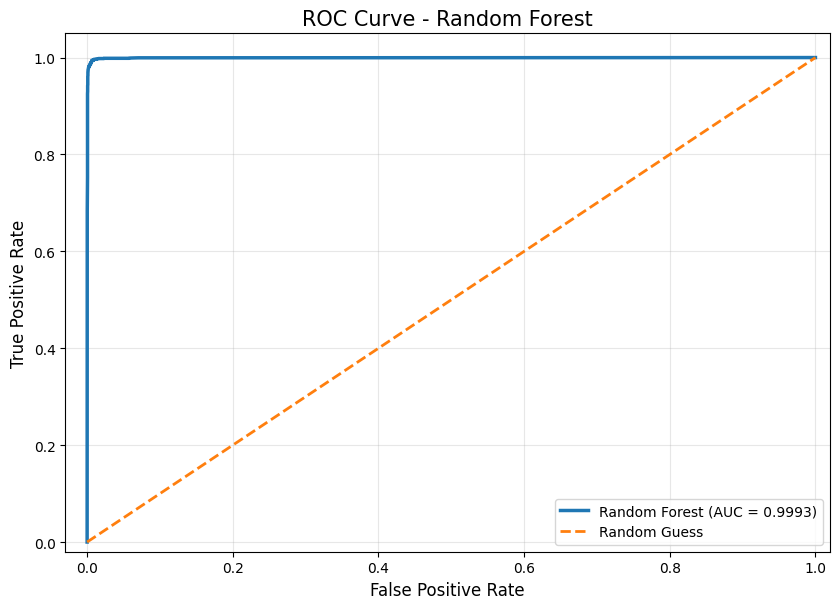


Feature Importance Method: Native


,Feature,Importance
0,punc_lt,0.176631
1,punc_gt,0.146150
2,combo_gt_lt,0.083698
3,tag_script,0.081504
4,punc_dquote,0.078489
5,symbols_ratio,0.076571
6,punc_lparen,0.033332
7,readability,0.028686
8,punc_comma,0.025919
9,punc_amp,0.022061


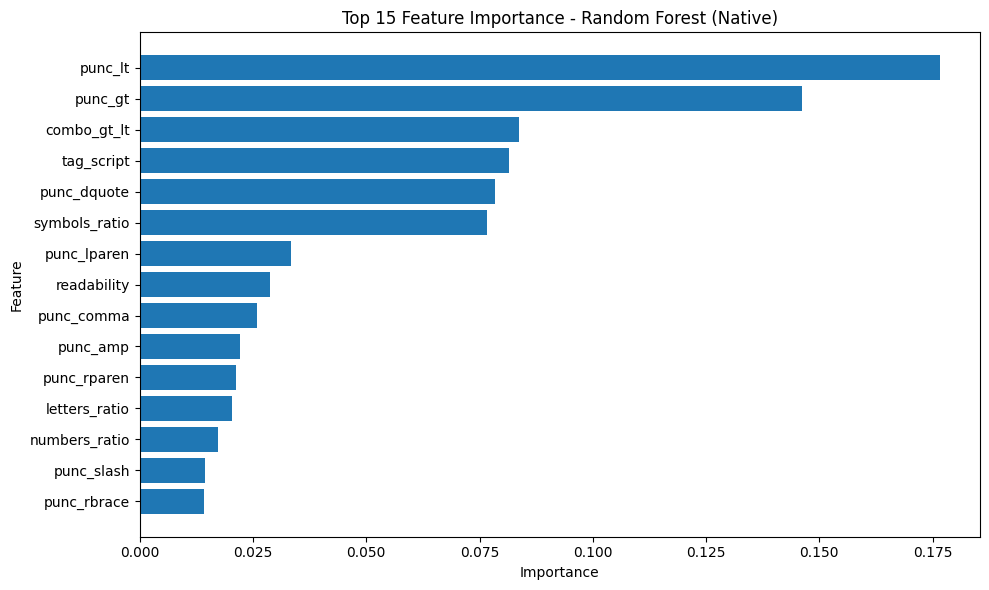


MODEL: KNN

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5588,25
Actual Positive (1),28,1921



Performance:
Execution time (sec): 1.4685
RAM peak (MB):        398.73
CPU peak (%):         119.20


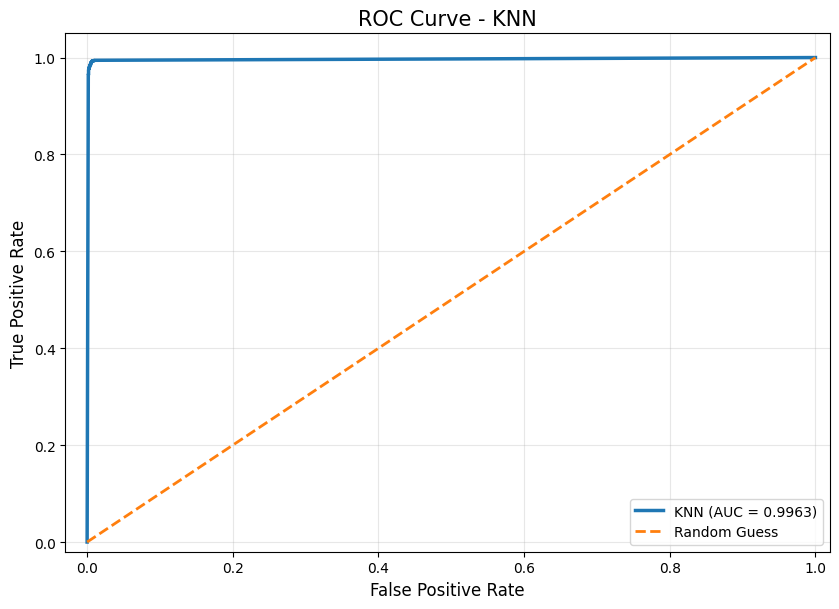


Feature Importance Method: Permutation


,Feature,Importance
0,punc_eq,0.034382
1,punc_space,0.032637
2,readability,0.005184
3,punc_colon,0.001494
4,mth_search,0.001203
5,punc_comma,0.001111
6,punc_dot,0.001005
7,tag_script,0.000939
8,proto_http,0.000912
9,punc_dquote,0.000873


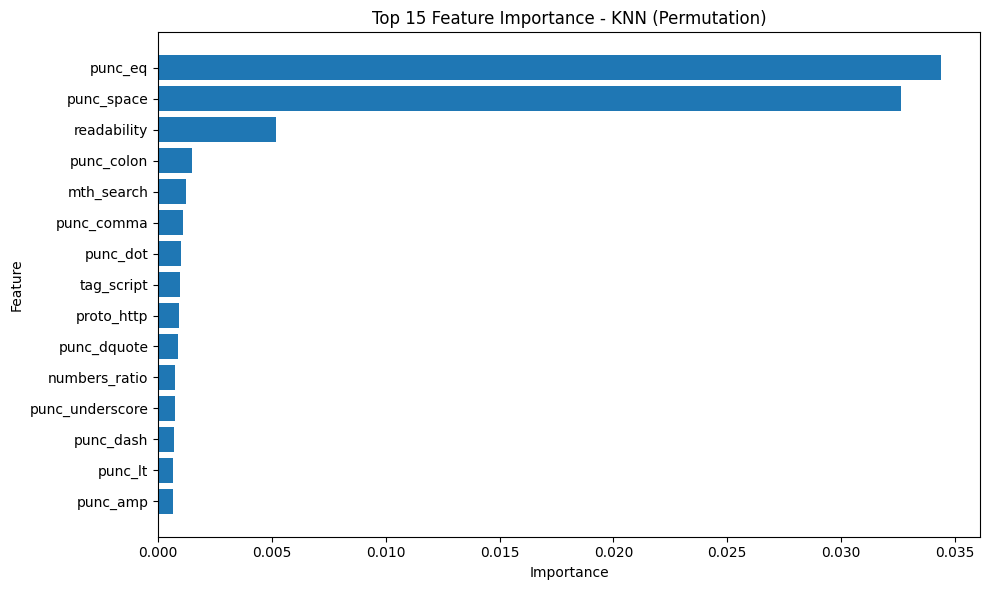


MODEL: SVM Poly

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5584,29
Actual Positive (1),14,1935



Performance:
Execution time (sec): 2.3773
RAM peak (MB):        486.59
CPU peak (%):         119.10


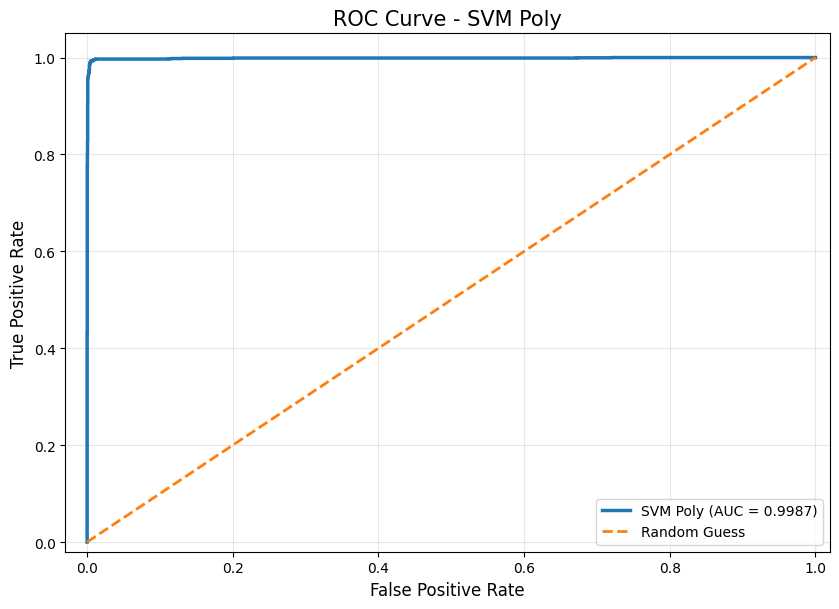


Feature Importance Method: Permutation


,Feature,Importance
0,punc_amp,0.203623
1,punc_eq,0.154218
2,punc_space,0.103994
3,punc_gt,0.032346
4,readability,0.029344
5,punc_comma,0.010540
6,punc_dot,0.004351
7,punc_dquote,0.003742
8,punc_bslash,0.003570
9,punc_rparen,0.003518


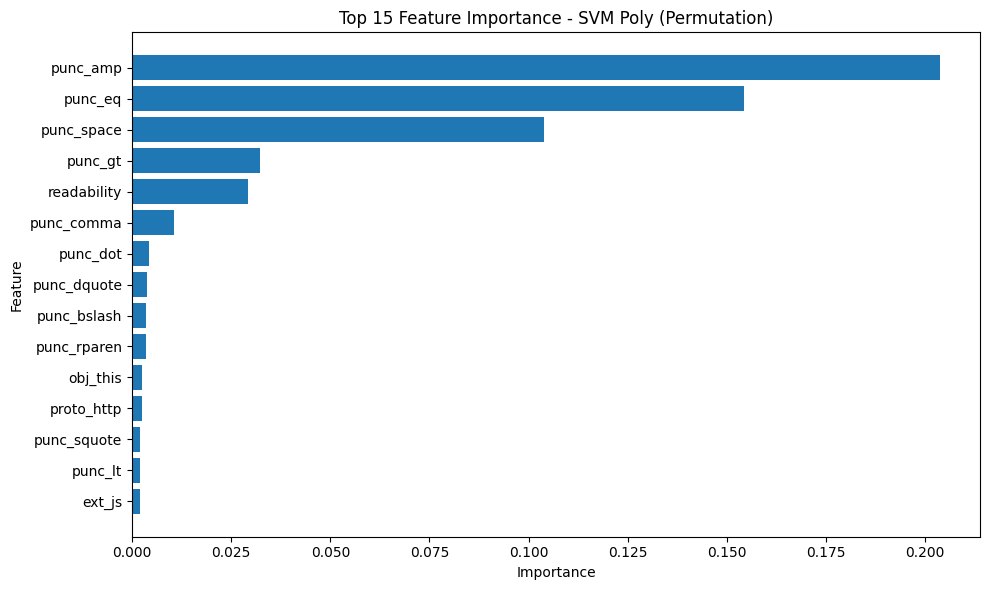


MODEL: SVM Linear

Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),5571,42
Actual Positive (1),53,1896



Performance:
Execution time (sec): 0.6753
RAM peak (MB):        456.77
CPU peak (%):         139.10


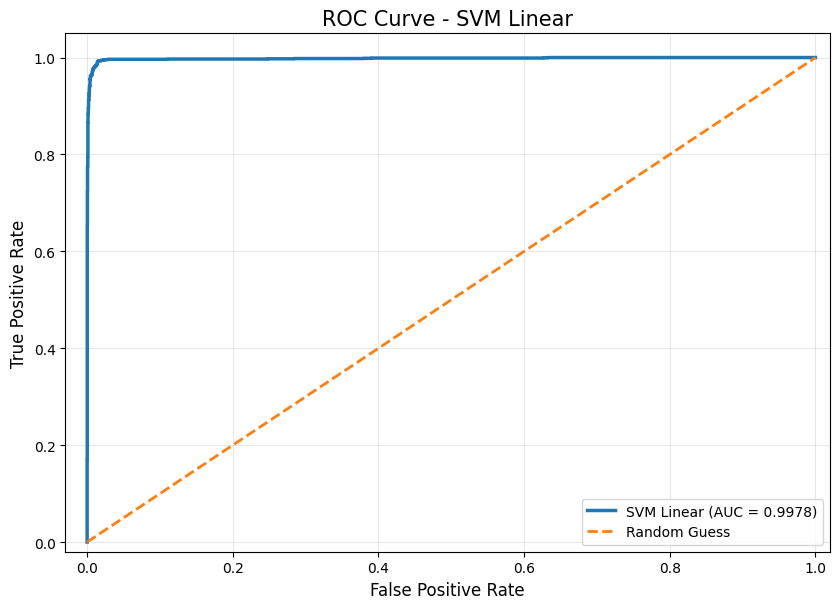


Feature Importance Method: Permutation


,Feature,Importance
0,punc_lt,0.051217
1,punc_comma,0.005104
2,punc_amp,0.004774
3,punc_lbrace,0.003518
4,readability,0.002989
5,punc_gt,0.002407
6,tag_script,0.002301
7,mth_fromcharcode,0.002156
8,punc_space,0.001865
9,punc_colon,0.001851


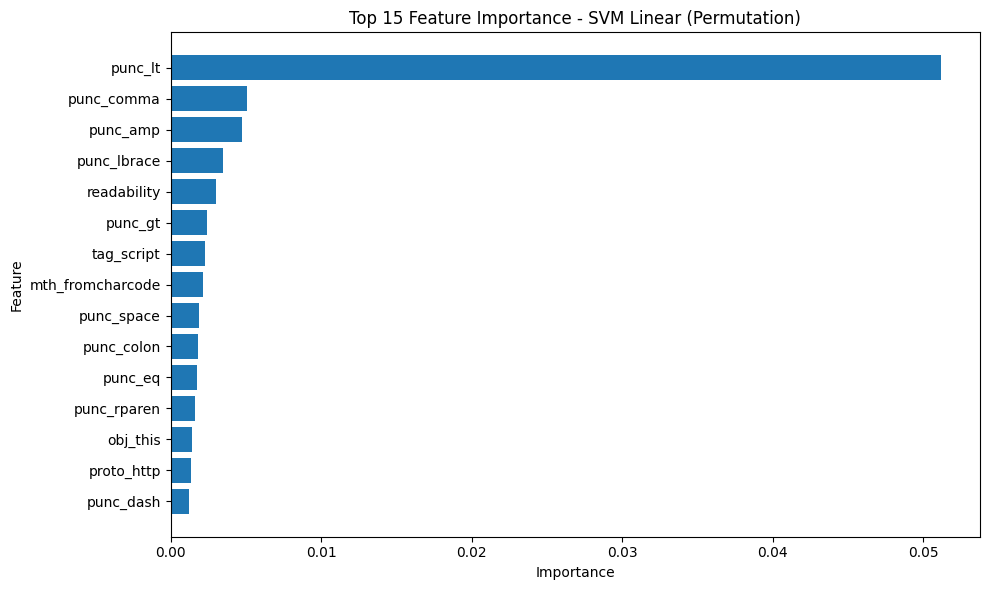


SUMMARY RESULTS


,Model,Accuracy,Precision,Sensitivity,Specificity,AUC,Execution Time (sec),RAM Peak (MB),CPU Peak (%),Importance Method
0,SVM Poly,0.9943,0.9852,0.9928,0.9948,0.9987,2.3773,486.5938,119.1,Permutation
1,Random Forest,0.9930,0.9837,0.9892,0.9943,0.9993,4.9622,398.7227,119.2,Native
2,KNN,0.9930,0.9872,0.9856,0.9955,0.9963,1.4685,398.7266,119.2,Permutation
3,SVM Linear,0.9874,0.9783,0.9728,0.9925,0.9978,0.6753,456.7656,139.1,Permutation



TOP 10 IMPORTANT FEATURES

Top 10 - Random Forest


,Feature,Importance
0,punc_lt,0.176631
1,punc_gt,0.146150
2,combo_gt_lt,0.083698
3,tag_script,0.081504
4,punc_dquote,0.078489
5,symbols_ratio,0.076571
6,punc_lparen,0.033332
7,readability,0.028686
8,punc_comma,0.025919
9,punc_amp,0.022061



Top 10 - KNN


,Feature,Importance
0,punc_eq,0.034382
1,punc_space,0.032637
2,readability,0.005184
3,punc_colon,0.001494
4,mth_search,0.001203
5,punc_comma,0.001111
6,punc_dot,0.001005
7,tag_script,0.000939
8,proto_http,0.000912
9,punc_dquote,0.000873



Top 10 - SVM Poly


,Feature,Importance
0,punc_amp,0.203623
1,punc_eq,0.154218
2,punc_space,0.103994
3,punc_gt,0.032346
4,readability,0.029344
5,punc_comma,0.010540
6,punc_dot,0.004351
7,punc_dquote,0.003742
8,punc_bslash,0.003570
9,punc_rparen,0.003518



Top 10 - SVM Linear


,Feature,Importance
0,punc_lt,0.051217
1,punc_comma,0.005104
2,punc_amp,0.004774
3,punc_lbrace,0.003518
4,readability,0.002989
5,punc_gt,0.002407
6,tag_script,0.002301
7,mth_fromcharcode,0.002156
8,punc_space,0.001865
9,punc_colon,0.001851


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import threading
import os
import psutil
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    auc
)
from sklearn.inspection import permutation_importance

# =======================
# Display helper
# =======================
def safe_display(obj):
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

# =========================
# 1. Đọc dữ liệu
# =========================
train_path = "/content/drive/MyDrive/ATPM/train.csv"
test_path = "/content/drive/MyDrive/ATPM/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# =========================
# 2. Tách X, y
# =========================
if "label" in train_df.columns and "label" in test_df.columns:
    X_train = train_df.drop(columns=["label"])
    y_train = train_df["label"]

    X_test = test_df.drop(columns=["label"])
    y_test = test_df["label"]
else:
    X_train = train_df.iloc[:, :-1]
    y_train = train_df.iloc[:, -1]

    X_test = test_df.iloc[:, :-1]
    y_test = test_df.iloc[:, -1]

feature_names = X_train.columns.tolist()

# =========================
# 3. Model
# =========================
models = {
    "Random Forest": RandomForestClassifier(
        max_depth=None,
        min_samples_split=2,
        n_estimators=200,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ),
    "SVM Poly": SVC(
        kernel="poly",
        C=10,
        degree=3,
        gamma="scale",
        probability=False
    ),
    "SVM Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1,
            max_iter=5000,
            random_state=42
        ))
    ])
}

# =========================
# Helper
# =========================
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)

def plot_single_roc(y_true, y_score, model_name):
    if len(np.unique(y_true)) != 2:
        print(f"Không thể vẽ ROC cho {model_name}")
        return np.nan

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8.5, 6.2))
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curve - {model_name}", fontsize=15)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)

    plt.xlim(-0.03, 1.02)
    plt.ylim(-0.02, 1.05)

    plt.tight_layout()
    plt.show()

    return roc_auc

def get_feature_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        method = "Native"

    elif hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 1:
            importances = np.abs(coef)
        else:
            importances = np.mean(np.abs(coef), axis=0)
        method = "Native"

    else:
        perm = permutation_importance(
            model,
            X,
            y,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )
        importances = perm.importances_mean
        method = "Permutation"

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    return imp_df, method

def plot_top_features(imp_df, model_name, method_name, top_n=15):
    top_df = imp_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Feature Importance - {model_name} ({method_name})")
    plt.tight_layout()
    plt.show()

# =========================
# Performance monitor
# =========================
class ResourceMonitor:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.running = False
        self.thread = None
        self.cpu_peak = 0.0
        self.ram_peak_mb = 0.0

    def _monitor(self):
        # Prime cpu_percent để lần đo sau có ý nghĩa
        self.process.cpu_percent(interval=None)

        while self.running:
            try:
                cpu = self.process.cpu_percent(interval=None)
                ram_mb = self.process.memory_info().rss / (1024 ** 2)

                if cpu > self.cpu_peak:
                    self.cpu_peak = cpu
                if ram_mb > self.ram_peak_mb:
                    self.ram_peak_mb = ram_mb

                time.sleep(self.interval)
            except Exception:
                break

    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._monitor, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        if self.thread is not None:
            self.thread.join(timeout=1)

def evaluate_with_monitor(model, X_train, y_train, X_test):
    monitor = ResourceMonitor(interval=0.05)

    t0 = time.perf_counter()
    monitor.start()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    monitor.stop()
    t1 = time.perf_counter()
    y_score = get_scores(model, X_test)

    exec_time = t1 - t0

    return {
        "y_pred": y_pred,
        "y_score": y_score,
        "exec_time_sec": exec_time,
        "cpu_peak_percent": monitor.cpu_peak,
        "ram_peak_mb": monitor.ram_peak_mb
    }

# =========================
# Train + Evaluate
# =========================
results = []
all_importance_tables = {}

for name, model in models.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    # ==========================================================
    # Chỉ đo thời gian / RAM / CPU cho fit + predict + score
    # KHÔNG bao gồm feature importance
    # ==========================================================
    perf_out = evaluate_with_monitor(model, X_train, y_train, X_test)

    y_pred = perf_out["y_pred"]
    y_score = perf_out["y_score"]
    exec_time_sec = perf_out["exec_time_sec"]
    cpu_peak_percent = perf_out["cpu_peak_percent"]
    ram_peak_mb = perf_out["ram_peak_mb"]

    # ===== Metrics =====
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    else:
        specificity = 0

    # ===== Confusion Matrix =====
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Negative (0)", "Actual Positive (1)"][:cm.shape[0]],
        columns=["Predicted Negative (0)", "Predicted Positive (1)"][:cm.shape[1]]
    )

    print("\nConfusion Matrix:")
    safe_display(cm_df)

    print("\nPerformance:")
    print(f"Execution time (sec): {exec_time_sec:.4f}")
    print(f"RAM peak (MB):        {ram_peak_mb:.2f}")
    print(f"CPU peak (%):         {cpu_peak_percent:.2f}")

    # ===== ROC =====
    roc_auc = plot_single_roc(y_test, y_score, name)

    # ===== Feature Importance =====
    # Phần này KHÔNG tính vào execution time / RAM / CPU ở trên
    imp_df, imp_method = get_feature_importance(
        model,
        X_test,
        y_test,
        feature_names
    )

    all_importance_tables[name] = imp_df.copy()

    print(f"\nFeature Importance Method: {imp_method}")
    safe_display(imp_df.head(15).round(6))

    plot_top_features(imp_df, name, imp_method)

    # ===== Save =====
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": roc_auc,
        "Execution Time (sec)": exec_time_sec,
        "RAM Peak (MB)": ram_peak_mb,
        "CPU Peak (%)": cpu_peak_percent,
        "Importance Method": imp_method
    })

# =========================
# SUMMARY
# =========================
print("\n" + "=" * 70)
print("SUMMARY RESULTS")
print("=" * 70)

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

safe_display(results_df)

# =========================
# Top importance
# =========================
print("\n" + "=" * 70)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 70)

for model_name, imp_df in all_importance_tables.items():
    print(f"\nTop 10 - {model_name}")
    safe_display(imp_df.head(10).round(6))

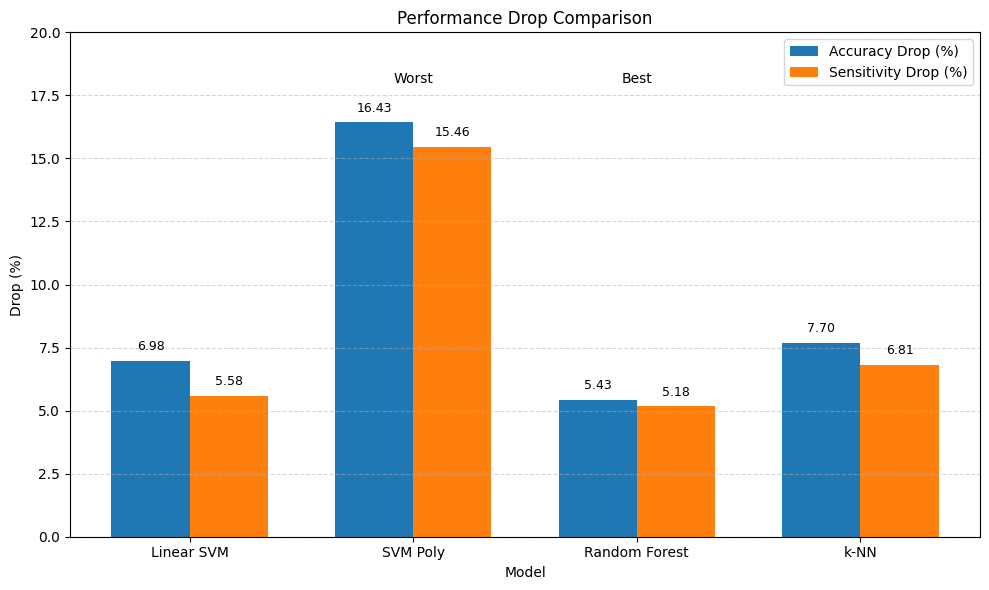

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
models = ["Linear SVM", "SVM Poly", "Random Forest", "k-NN"]
accuracy_drop = [6.98, 16.43, 5.43, 7.70]
sensitivity_drop = [5.58, 15.46, 5.18, 6.81]

# =========================
# Setup vị trí cột
# =========================
x = np.arange(len(models))
width = 0.35

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, accuracy_drop, width, label="Accuracy Drop (%)")
bars2 = plt.bar(x + width/2, sensitivity_drop, width, label="Sensitivity Drop (%)")

# =========================
# Label + title
# =========================
plt.xlabel("Model")
plt.ylabel("Drop (%)")
plt.title("Performance Drop Comparison")
plt.xticks(x, models)
plt.legend()

# =========================
# Hiển thị giá trị trên cột
# =========================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.3,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)

# =========================
# Highlight best/worst (optional)
# =========================
# Random Forest tốt nhất
best_idx = models.index("Random Forest")
plt.text(x[best_idx], 18, "Best", ha='center', fontsize=10)

# SVM Poly tệ nhất
worst_idx = models.index("SVM Poly")
plt.text(x[worst_idx], 18, "Worst", ha='center', fontsize=10)

# =========================
# Layout đẹp hơn
# =========================
plt.ylim(0, 20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()